# correlation_v03: amount-greedy base + Pareto tracking-risk optimization


## 环境与依赖

In [76]:
from __future__ import annotations

import json
import math
import os
import re
import sys
import time
import hashlib
import warnings
from datetime import date, datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import requests
from IPython.display import display

from xtquant import xtdatacenter as xtdc
from xtquant import xtdata
xtdata.reconnect(port = 58610)

PROJECT_ROOT = Path.cwd().resolve()

BASE_URL = "https://quantapi.51ifind.com/api/v1"

# ========== 指数配置：改 INDEX_CODE 即可切换 ==========
# INDEX_CODE = "000016"  # 上证50
INDEX_CODE = "000300"  # 沪深300
# INDEX_CODE = "000905"  # 中证500
# INDEX_CODE = "000852"  # 中证1000
# INDEX_CODE = "000688"  # 科创50

INDEX_META = {
    "000016": {"name": "上证50", "ths": "000016.SH", "futures": "IH00.CFE", "primary_etf": "510050.SH"},
    "000300": {"name": "沪深300", "ths": "000300.SH", "futures": "IF00.CFE", "primary_etf": "510300.SH"},
    "000905": {"name": "中证500", "ths": "000905.SH", "futures": "IC00.CFE", "primary_etf": "510500.SH"},
    "000852": {"name": "中证1000", "ths": "000852.SH", "futures": "IM00.CFE", "primary_etf": "512100.SH"},
    "000688": {"name": "科创50", "ths": "000688.SH", "futures": "IC00.CFE", "primary_etf": "588000.SH"},
}

EX_DIVIDEND_COLUMN_MAP = {
    "thscode": "股票代码",
    "time": "报告期_财报期末",
    "ths_ex_dividend_date_stock": "除权除息日",
    "ths_dividend_ps_before_tax_stock": "每股派息_税前",
    "ths_bonus_shares_ps_stock": "每股送股",
}

LIMIT_STATUS_COLUMN_MAP = {
    "thscode": "股票代码",
    "time": "状态日期",
    "ths_up_and_down_status_stock": "涨跌停状态",
    "is_limit_up": "前日是否涨停",
    "is_limit_down": "前日是否跌停",
    "is_suspended": "前日是否停牌",
    "can_trade_today_hint": "今日交易参考",
}

SSE_QUERY_URL = "https://query.sse.com.cn/commonQuery.do"
SSE_REFERER = "https://www.sse.com.cn/disclosure/fund/etflist/"
SSE_COMPONENT_SQL_ID = "COMMON_SSE_CP_JJLB_ETFJJGK_GGSGSHQD_COMPONENT_C"

PRICE_TOLERANCE = 0.0001

if INDEX_CODE not in INDEX_META:
    raise RuntimeError(f"ifind_import_helpers.INDEX_META 未配置指数 {INDEX_CODE}")
index_meta = INDEX_META[INDEX_CODE]
index_name = index_meta["name"]
print("项目目录:", PROJECT_ROOT)
print("指数:", INDEX_CODE, index_name)


***** xtdata连接成功 2026-07-27 11:39:56*****
服务信息: {'tag': 'qmt_research', 'version': '1.0'}
服务地址: 127.0.0.1:58610
数据路径: E:\迅投极速交易终端睿智融科版\datadir
设置xtdata.enable_hello = False可隐藏此消息

项目目录: E:\Codex\系统\Stock-Index-Fitting
指数: 000300 沪深300


In [77]:
from utils import (read_daily_data, read_csi_file, build_run_paths, read_stocks_ticks,
                   SseEtfPcfScraper, print_preview, resolve_sse50_etf_codes, save_outputs, download_csi_constituent_v02,
                   fetch_szse_pcf)
from utils import gogoal_query
from utils.tick_analysis_v03 import (
    build_corporate_action_quantity_schedule,
    standardize_corporate_actions,
    build_minute_tracking_analysis,
    combine_minute_tracking_results,
    save_tracking_outputs,
)
from utils.risk_model_v03 import build_shrunk_risk_model_from_daily_loader
from utils.minute_tick_cache_v03 import (
    build_minute_tick_cache,
    load_minute_tick_cache,
    save_minute_tick_cache,
)
from utils.pareto_risk_optimizer_v02 import (
    ParetoOptimizerConfig,
    optimize_portfolio_pareto_risk,
    build_size_exposure_report,
)


## 参数设置

In [78]:
# Trading rule file.
# security_buy_rules_special.csv: min quantity 1, step 1.
# security_buy_rules.csv: normal exchange-style rules.
rule_file_path = "security_buy_rules.csv"
# rule_file_path = "security_buy_rules_special.csv"
# rule_file_path = "security_buy_rules_adjusted.csv"

# Fixed capital allocated to the stock basket.
target_stock_value = 1_500_000.0

# v02 construction is fixed to two phases:
# 1. amount greedy builds a legal basket inside the funding interval;
# 2. Pareto local search applies add/reduce/one-to-one swap actions.
portfolio_greedy_method = "amount_greedy_pareto_risk"

# Risk model: five trading days ending on the pricing date, 1m lastPrice
# log returns, no overnight returns, three-day half-life, automatic OAS shrinkage.
# Matrix used by the optimizer: "covariance" or "correlation".
risk_matrix_mode = "correlation"
risk_lookback_days = 5
risk_half_life_days = 3.0
risk_price_col = "lastPrice"

# Pareto candidate and beam controls.
pareto_risk_candidate_count = 20
pareto_amount_candidate_count = 20
pareto_beam_width = 40
pareto_max_rounds = 50
pareto_stale_rounds_to_stop = 3
pareto_legal_neighbor_steps = 3

# baseline_date is used to read closes and build the initial basket.
# fitting_date_ls is used to read 1m ticks and evaluate the basket.
baseline_date = "20260708"
fitting_date_ls = ["20260708", "20260709"]

# Dates when the existing basket is rebuilt before market open.
# Each adjustment uses the previous trading day's weight list and close prices.
adjusting_date_ls = []

# Stocks excluded from every basket. Use 6-digit or exchange-suffixed codes.
# excepted_code_ls = ["300308", "600900"]
excepted_code_ls = []

# True: derive index weights from the primary ETF PCF on baseline_date.
# False: use the existing CSI/projected-weight source flow.
using_etf = False

# Every completed base/local-search state must remain in
# [target_stock_value, target_stock_value * adjustment_max_over_budget_ratio].
adjustment_allow_over_budget = True
adjustment_max_over_budget_ratio = 1.005

# Whether stock dividends / transfer shares are reflected in basket valuation.
apply_corporate_actions_to_basket = True

# Real index minute price caliber: "preClose", "open", or "close".
real_index_price_caliber = "close"

# Real index amount calculation mode.
real_index_amount_mode = "basket_base_scaled"


In [79]:
def get_previous_closest_trading_date(current_date: str) -> str:

    target_date = pd.Timestamp(current_date)

    start_date = (target_date - pd.Timedelta(days=366)).strftime("%Y%m%d")

    calendar = xtdata.get_trading_calendar(
        "SH",
        start_time=start_date,
        end_time=current_date,
    )

    trading_dates = sorted({
        "".join(ch for ch in str(item) if ch.isdigit())[:8]
        for item in (calendar or [])
    })

    available_dates = [
        trade_date
        for trade_date in trading_dates
        if trade_date < current_date
    ]

    if not available_dates:
        raise RuntimeError(
            f"无法找到 {current_date} 之前的交易日，请检查迅投交易日历数据。"
        )

    return available_dates[-1]

In [80]:
# Validate configured trade dates with xt trading calendar
# Assumption: baseline_date, fitting_date_ls, and adjusting_date_ls all use YYYYMMDD strings.
if len(fitting_date_ls) != 2:
    _configured_trade_dates = list(fitting_date_ls) + list(adjusting_date_ls)
    _non_trading_dates = []

    for _trade_date in _configured_trade_dates:
        _trade_date = str(_trade_date)
        _calendar = xtdata.get_trading_calendar("SH", start_time=_trade_date, end_time=_trade_date)
        if len(_calendar) == 0:
            _non_trading_dates.append(_trade_date)

    if _non_trading_dates:
        raise RuntimeError(f"Configured dates contain non-trading days according to xt SH calendar: {_non_trading_dates}")
else:
    _calendar = xtdata.get_trading_calendar("SH", start_time=fitting_date_ls[0], end_time=fitting_date_ls[0])
    if len(_calendar) == 0:
        _date = get_previous_closest_trading_date(fitting_date_ls[0])
        print(f"Illegal start date {fitting_date_ls[0]}, switch to the closest previous trading day {_date}")
        fitting_date_ls[0] = _date

    _calendar = xtdata.get_trading_calendar("SH", start_time=fitting_date_ls[1], end_time=fitting_date_ls[1])
    if len(_calendar) == 0:
        _date = get_previous_closest_trading_date(fitting_date_ls[1])
        print(f"Illegal end date {fitting_date_ls[1]}, switch to the closest previous trading day {_date}")
        fitting_date_ls[1] = _date

    trading_timestamps = xtdata.get_trading_dates("SH")

    trading_days = (
        pd.to_datetime(trading_timestamps, unit="ms", utc=True)
        .tz_convert("Asia/Shanghai")
        .strftime("%Y%m%d")
        .tolist()
    )

    result =  [
        d for d in trading_days
        if fitting_date_ls[0] <= d <= fitting_date_ls[1]
    ]

    fitting_date_ls = result

if baseline_date >= fitting_date_ls[0]:
    baseline_date = get_previous_closest_trading_date(fitting_date_ls[0])
    print(f"Baseline date {baseline_date} adjusted to the closest previous trading day before fitting start date {fitting_date_ls[0]}")
print("XT trading calendar validation passed:")


Baseline date 20260707 adjusted to the closest previous trading day before fitting start date 20260708
XT trading calendar validation passed:


## 重复使用的辅助函数

In [81]:
def to_xt_stock_code(code) -> str:
    text = str(code).strip()
    if "." in text:
        left, right = text.split(".", 1)
        return f"{left.zfill(6)}.{right.upper()}"

    code6 = text.zfill(6)
    if code6.startswith(("6", "9")):
        return f"{code6}.SH"
    if code6.startswith(("0", "2", "3")):
        return f"{code6}.SZ"
    if code6.startswith(("4", "8")):
        return f"{code6}.BJ"
    raise ValueError(f"无法识别证券代码市场: {code}")

def normalize_stock_code(value) -> str:
    raw = str(value).strip().upper()
    if raw.endswith((".SH", ".SZ", ".BJ")):
        return raw
    digits = raw.split(".")[0].zfill(6)
    return f"{digits}.SH" if digits.startswith(("5", "6", "9")) else f"{digits}.SZ"


def require_columns(frame: pd.DataFrame, columns: list[str], label: str) -> None:
    missing = [c for c in columns if c not in frame.columns]
    if missing:
        raise RuntimeError(f"{label} 缺少明确字段 {missing}；实际字段={frame.columns.tolist()}")


def save_csv(frame: pd.DataFrame, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"已保存: {path} shape={frame.shape}")


def show_frame(label: str, frame: pd.DataFrame, rows: int = 5) -> None:
    print(f"{label}: shape={frame.shape}")
    print("字段:", frame.columns.tolist())
    display(frame.head(rows))


def floor_legal_quantity(quantity: float, minimum: int, step: int) -> int:
    if quantity < minimum:
        return 0
    return int(minimum + math.floor((quantity - minimum) / step) * step)


def sql_literal(value) -> str:
    return "'" + str(value).replace("'", "''") + "'"


def sql_in(values) -> str:
    vals = list(values)
    if not vals:
        raise ValueError("SQL IN 列表为空")
    return ", ".join(sql_literal(v) for v in vals)


def strip_market_suffix(value) -> str:
    return str(value).strip().upper().split(".")[0].zfill(6)


def normalize_trade_date(value) -> str:
    return pd.Timestamp(value).strftime("%Y%m%d")


def normalize_trade_date_dash(value) -> str:
    return pd.Timestamp(value).strftime("%Y-%m-%d")



def fetch_gogoal_index_close(index_code: str, trade_date: str) -> pd.DataFrame:
    sql = f"""
        SELECT trade_date, index_code, index_name, tclose, lclose, is_valid
        FROM qt_idx_daily
        WHERE index_code = {sql_literal(index_code)}
          AND trade_date = {sql_literal(normalize_trade_date_dash(trade_date))}
          AND is_valid = 1
    """
    return gogoal_query(sql, output_format="dataframe")


def fetch_gogoal_stock_closes(stock_codes: list[str], trade_date: str) -> pd.DataFrame:
    stripped_codes = [strip_market_suffix(code) for code in stock_codes]
    sql = f"""
        SELECT trade_date, stock_code, stock_name, tclose, lclose, is_valid
        FROM qt_stk_daily
        WHERE trade_date = {sql_literal(normalize_trade_date_dash(trade_date))}
          AND stock_code IN ({sql_in(stripped_codes)})
          AND is_valid = 1
    """
    raw = gogoal_query(sql, output_format="dataframe")
    if raw.empty:
        return pd.DataFrame(columns=["stock_code", "gogoal_close", "gogoal_lclose", "stock_name_gogoal"])
    raw["stock_code"] = raw["stock_code"].map(normalize_stock_code)
    return raw.rename(columns={
        "stock_name": "stock_name_gogoal",
        "tclose": "gogoal_close",
        "lclose": "gogoal_lclose",
    })[["stock_code", "stock_name_gogoal", "gogoal_close", "gogoal_lclose"]]


def fetch_gogoal_corporate_actions(stock_codes: list[str], start_date: str, end_date: str) -> pd.DataFrame:
    stripped_codes = [strip_market_suffix(code) for code in stock_codes]
    sql = f"""
        SELECT
            stock_code,
            stock_name,
            declare_date,
            xr_xd_date AS ex_date,
            beftax_maxcashdiv,
            beftax_mincashdiv,
            aftax_cashdiv,
            stockdiv_ratio,
            trans_ratio,
            bonus_ratio,
            is_newest,
            is_valid
        FROM bas_stk_hisdistribution
        WHERE stock_code IN ({sql_in(stripped_codes)})
          AND xr_xd_date >= {sql_literal(normalize_trade_date_dash(start_date))}
          AND xr_xd_date <= {sql_literal(normalize_trade_date_dash(end_date))}
          AND is_valid = 1
    """
    raw = gogoal_query(sql, output_format="dataframe")
    if raw.empty:
        return pd.DataFrame(columns=["stock_code", "ex_date"])
    raw["stock_code"] = raw["stock_code"].map(normalize_stock_code)
    raw["ex_date"] = pd.to_datetime(raw["ex_date"], errors="coerce").dt.strftime("%Y-%m-%d")
    return raw

def to_xt_etf_code(code) -> str:
    text = str(code).strip()
    if "." in text:
        left, right = text.split(".", 1)
        return f"{left.zfill(6)}.{right.upper()}"

    code6 = text.zfill(6)
    if code6.startswith(("5", "6")):
        return f"{code6}.SH"
    if code6.startswith(("1", "15", "16", "18")):
        return f"{code6}.SZ"
    return to_xt_stock_code(code6)

# ---- v10 adjustment helpers ----
def get_previous_index_trade_date(trade_date: str) -> tuple[str, str]:
    trade_date_dash = normalize_trade_date_dash(trade_date)
    df_prev = gogoal_query(f"""
        SELECT MAX(trade_date) AS prev_trade_date
        FROM qt_idx_daily
        WHERE index_code = {sql_literal(INDEX_CODE)}
          AND trade_date < {sql_literal(trade_date_dash)}
          AND is_valid = 1
    """, output_format="dataframe")
    if df_prev.empty or pd.isna(df_prev["prev_trade_date"].iloc[0]):
        raise RuntimeError(f"Cannot resolve previous index trade date before {trade_date_dash}.")
    prev_dash = pd.Timestamp(df_prev["prev_trade_date"].iloc[0]).strftime("%Y-%m-%d")
    return prev_dash.replace("-", ""), prev_dash


def get_index_trade_dates(start_exclusive: str, end_inclusive: str) -> list[str]:
    start_dash = normalize_trade_date_dash(start_exclusive)
    end_dash = normalize_trade_date_dash(end_inclusive)
    df_dates = gogoal_query(f"""
        SELECT trade_date
        FROM qt_idx_daily
        WHERE index_code = {sql_literal(INDEX_CODE)}
          AND trade_date > {sql_literal(start_dash)}
          AND trade_date <= {sql_literal(end_dash)}
          AND is_valid = 1
        ORDER BY trade_date
    """, output_format="dataframe")
    if df_dates.empty:
        raise RuntimeError(f"No index trade dates between {start_dash} and {end_dash}.")
    return [pd.Timestamp(item).strftime("%Y%m%d") for item in df_dates["trade_date"]]


def read_local_projected_index_weights(date: str) -> pd.DataFrame:
    date = normalize_trade_date(date)
    path = Path(r"data\weights_projection") / f"{INDEX_CODE}-{date}.csv"
    if not path.is_file():
        raise FileNotFoundError(f"Projected weight file not found: {path}")
    df = pd.read_csv(path)
    require_columns(df, ["stock_code", "stock_name", "projected_weight_pct"], f"projected weights {path}")
    out = pd.DataFrame({
        "stock_code": df["stock_code"].map(normalize_stock_code),
        "stock_name": df["stock_name"].astype(str).str.strip(),
        "raw_weight_pct": pd.to_numeric(df["projected_weight_pct"], errors="coerce"),
        "closeweight_data_date": normalize_trade_date_dash(date),
        "weight_source": "PROJECTED_LOCAL",
        "weight_file_path": str(path),
        "import_time": import_time,
    })
    out = out.dropna(subset=["stock_code", "raw_weight_pct"])
    out = out[out["raw_weight_pct"] > 0].drop_duplicates("stock_code").sort_values("stock_code").reset_index(drop=True)
    if out.empty:
        raise RuntimeError(f"Projected weight file has no valid positive weights: {path}")
    return out


def read_local_etf_pcf_for_date(pcf_date: str) -> pd.DataFrame:
    pcf_date = normalize_trade_date(pcf_date)
    base_dir = PROJECT_ROOT / "data" / "etf_pcf"
    preferred = base_dir / index_name / f"{pcf_date}_sse.csv"
    if preferred.is_file():
        path = preferred
    else:
        matches = sorted(base_dir.glob(f"*/{pcf_date}_sse.csv"))
        if not matches:
            raise FileNotFoundError(f"Local ETF PCF file not found for {pcf_date}: {preferred}")
        path = matches[0]
    df = pd.read_csv(path)
    require_columns(df, ["stock_code", "stock_name", "component_qty"], f"local ETF PCF {path}")
    df = df.copy()
    df["stock_code"] = df["stock_code"].map(normalize_stock_code)
    df["component_qty"] = pd.to_numeric(df["component_qty"], errors="coerce")
    df = df.dropna(subset=["stock_code", "component_qty"])
    df = df[df["component_qty"] > 0]
    if df.empty:
        raise RuntimeError(f"Local ETF PCF has no positive component_qty rows: {path}")
    df["source_file_path"] = str(path)
    return df


def derive_index_weights_from_etf_pcf(df_pcf: pd.DataFrame, pcf_date: str) -> dict:
    pcf_date = normalize_trade_date(pcf_date)
    pcf_date_dash = normalize_trade_date_dash(pcf_date)
    require_columns(df_pcf, ["stock_code", "stock_name", "component_qty"], "ETF PCF")
    components = df_pcf[["stock_code", "stock_name", "component_qty"]].copy()
    components["stock_code"] = components["stock_code"].map(normalize_stock_code)
    components["component_qty"] = pd.to_numeric(components["component_qty"], errors="coerce")
    components = components.dropna(subset=["stock_code", "component_qty"])
    components = components[components["component_qty"] > 0]
    components = (
        components.groupby("stock_code", as_index=False)
        .agg(stock_name=("stock_name", "first"), component_qty=("component_qty", "sum"))
    )
    if components.empty:
        raise RuntimeError("ETF PCF has no valid component rows after aggregation.")

    etf_weight_price_date, etf_weight_price_date_dash = get_previous_index_trade_date(pcf_date)
    df_prev_close = fetch_gogoal_stock_closes(components["stock_code"].tolist(), etf_weight_price_date)
    if df_prev_close.empty:
        raise RuntimeError(f"Empty previous close data for ETF components: {etf_weight_price_date}.")
    df_prev_close["gogoal_close"] = pd.to_numeric(df_prev_close["gogoal_close"], errors="coerce")

    source = components.merge(
        df_prev_close[["stock_code", "gogoal_close"]],
        on="stock_code", how="left", validate="one_to_one",
    )
    invalid = source["gogoal_close"].isna() | (source["gogoal_close"] <= 0)
    if invalid.any():
        display(source.loc[invalid])
        raise RuntimeError("Some ETF PCF components have missing or invalid previous close prices.")

    source["component_amount"] = source["component_qty"] * source["gogoal_close"]
    total_component_amount = float(source["component_amount"].sum())
    if not np.isfinite(total_component_amount) or total_component_amount <= 0:
        raise RuntimeError("ETF PCF component amount sum is not positive.")

    etf_code_value = resolved_etf if "resolved_etf" in globals() else index_meta.get("primary_etf", "")
    weights = pd.DataFrame({
        "stock_code": source["stock_code"],
        "stock_name": source["stock_name"].astype(str).str.strip(),
        "raw_weight_pct": source["component_amount"] / total_component_amount * 100.0,
        "closeweight_data_date": pcf_date_dash,
        "weight_source": "ETF_PCF_LOCAL",
        "etf_code": etf_code_value,
        "etf_pcf_trade_date": pcf_date,
        "etf_weight_price_date": etf_weight_price_date,
        "component_qty": source["component_qty"],
        "component_prev_close": source["gogoal_close"],
        "component_amount": source["component_amount"],
        "import_time": import_time,
    }).sort_values("stock_code").reset_index(drop=True)

    cons = weights[["stock_code", "stock_name"]].copy()
    cons["cons_data_date"] = pcf_date_dash
    cons["import_time"] = import_time

    check = pd.DataFrame([{
        "weight_count": len(weights),
        "cons_count": len(cons),
        "closeweight_data_date": pcf_date_dash,
        "cons_data_date": pcf_date_dash,
        "only_in_weights": "",
        "only_in_cons": "",
        "is_consistent": set(weights["stock_code"]) == set(cons["stock_code"]),
        "weight_source": "ETF_PCF_LOCAL",
        "etf_code": etf_code_value,
        "etf_pcf_trade_date": pcf_date,
        "etf_weight_price_date": etf_weight_price_date,
        "component_amount_sum": total_component_amount,
        "raw_weight_sum": float(weights["raw_weight_pct"].sum()),
        "import_time": import_time,
    }])
    return {
        "df_index_weights": weights,
        "df_index_cons": cons,
        "df_index_check": check,
        "df_etf_weight_source": source,
        "etf_weight_price_date": etf_weight_price_date,
        "etf_weight_price_date_dash": etf_weight_price_date_dash,
    }


def load_index_weights_for_date(weight_date: str) -> dict:
    weight_date = normalize_trade_date(weight_date)
    weight_date_dash = normalize_trade_date_dash(weight_date)
    if using_etf:
        pcf = read_local_etf_pcf_for_date(weight_date)
        loaded = derive_index_weights_from_etf_pcf(pcf, weight_date)
        loaded["df_official_pcf"] = pcf
        loaded["weight_date"] = weight_date
        loaded["weight_date_dash"] = weight_date_dash
        return loaded

    weights = read_local_projected_index_weights(weight_date)
    cons = weights[["stock_code", "stock_name"]].copy()
    cons["cons_data_date"] = weight_date_dash
    cons["import_time"] = import_time
    check = pd.DataFrame([{
        "weight_count": len(weights),
        "cons_count": len(cons),
        "closeweight_data_date": weight_date_dash,
        "cons_data_date": weight_date_dash,
        "only_in_weights": "",
        "only_in_cons": "",
        "is_consistent": set(weights["stock_code"]) == set(cons["stock_code"]),
        "weight_source": "PROJECTED_LOCAL",
        "raw_weight_sum": float(weights["raw_weight_pct"].sum()),
        "import_time": import_time,
    }])
    return {
        "df_index_weights": weights,
        "df_index_cons": cons,
        "df_index_check": check,
        "weight_date": weight_date,
        "weight_date_dash": weight_date_dash,
    }


def build_component_rules_from_weights(df_weights: pd.DataFrame, df_security_rules: pd.DataFrame) -> pd.DataFrame:
    frame = df_weights.copy()
    frame["stock_code"] = frame["stock_code"].map(normalize_stock_code)
    frame["exchange"] = frame["stock_code"].str[-2:]
    frame["board"] = "MAIN"
    frame.loc[frame["stock_code"].str.startswith("68"), "board"] = "STAR"
    frame.loc[frame["stock_code"].str.startswith("30"), "board"] = "CHINEXT"
    frame.loc[frame["stock_code"].str.startswith("920"), "exchange"] = "BJ"
    frame.loc[frame["exchange"] == "BJ", "board"] = "MAIN"
    if (~frame["exchange"].isin(["SH", "SZ"])).any():
        raise RuntimeError("Unsupported exchange found in component rules.")
    frame = frame.merge(
        df_security_rules.drop(columns=["import_time"], errors="ignore"),
        on=["exchange", "board"], how="left", validate="many_to_one",
    )
    if frame[["buy_min_qty", "buy_qty_step"]].isna().any(axis=None):
        display(frame.loc[frame[["buy_min_qty", "buy_qty_step"]].isna().any(axis=1)])
        raise RuntimeError("Some components cannot match trading rules.")
    return frame


def build_target_portfolio_for_weights(
    df_weights: pd.DataFrame,
    pricing_date: str,
    target_value: float,
    df_security_rules: pd.DataFrame,
    *,
    allow_over_budget: bool = False,
    max_over_budget_ratio: float = 1.0,
    label: str = "rebalance",
    market_snapshot: pd.DataFrame | None = None,
    theoretical_portfolio: pd.DataFrame | None = None,
    excepted_code_ls: list[str] | None = None,
) -> dict:
    pricing_date = normalize_trade_date(pricing_date)
    target_value = float(target_value)
    if not np.isfinite(target_value) or target_value <= 0:
        raise RuntimeError(f"target_value must be positive for {label}: {target_value}")
    budget_limit = target_value * (float(max_over_budget_ratio) if allow_over_budget else 1.0)
    if budget_limit < target_value:
        raise RuntimeError("max_over_budget_ratio must be >= 1.0 when over-budget adjustment is enabled.")

    excepted_code_set = {normalize_stock_code(code) for code in (excepted_code_ls or [])}
    component_rules = build_component_rules_from_weights(df_weights, df_security_rules)
    stock_codes_local = component_rules["stock_code"].tolist()

    if theoretical_portfolio is None:
        closes = fetch_gogoal_stock_closes(stock_codes_local, pricing_date)
        if closes.empty:
            raise RuntimeError(f"Empty Go-Goal constituent close data for {label}: {pricing_date}")
        closes["gogoal_close"] = pd.to_numeric(closes["gogoal_close"], errors="coerce")
        market_snapshot = pd.DataFrame({"stock_code": stock_codes_local}).merge(closes, on="stock_code", how="left")
        market_snapshot["close_price"] = market_snapshot["gogoal_close"]
        market_snapshot["pricing_date"] = pricing_date
        market_snapshot["import_time"] = import_time
        invalid = market_snapshot["close_price"].isna() | (market_snapshot["close_price"] <= 0)
        if invalid.any():
            display(market_snapshot.loc[invalid])
            raise RuntimeError(f"Invalid close prices for {label}: {pricing_date}")

        theoretical = component_rules[[
            "stock_code", "stock_name", "raw_weight_pct", "exchange", "board", "buy_min_qty", "buy_qty_step"
        ]].merge(market_snapshot[["stock_code", "close_price"]], on="stock_code", validate="one_to_one")
        theoretical["raw_weight"] = theoretical["raw_weight_pct"] / theoretical["raw_weight_pct"].sum()
        theoretical["target_stock_value"] = target_value
        theoretical["theoretical_amount"] = target_value * theoretical["raw_weight"]
        theoretical["theoretical_qty"] = theoretical["theoretical_amount"] / theoretical["close_price"]
        theoretical["pricing_date"] = pricing_date
        theoretical["portfolio_label"] = label
        theoretical["import_time"] = import_time
    else:
        theoretical = theoretical_portfolio.copy()
        require_columns(
            theoretical,
            [
                "stock_code", "stock_name", "raw_weight_pct", "exchange", "board",
                "buy_min_qty", "buy_qty_step", "close_price", "raw_weight",
                "target_stock_value", "theoretical_amount", "theoretical_qty",
            ],
            f"{label} theoretical portfolio",
        )
        theoretical["stock_code"] = theoretical["stock_code"].map(normalize_stock_code)
        theoretical["close_price"] = pd.to_numeric(theoretical["close_price"], errors="coerce")
        invalid = theoretical["close_price"].isna() | (theoretical["close_price"] <= 0)
        if invalid.any():
            display(theoretical.loc[invalid])
            raise RuntimeError(f"Invalid precomputed close prices for {label}: {pricing_date}")
        theoretical["portfolio_label"] = label
        theoretical["pricing_date"] = pricing_date
        theoretical["import_time"] = import_time
        if market_snapshot is None:
            market_snapshot = theoretical[["stock_code", "close_price", "pricing_date", "import_time"]].copy()
        else:
            market_snapshot = market_snapshot.copy()

    theoretical["is_excepted_code"] = theoretical["stock_code"].isin(excepted_code_set)
    target = theoretical.copy()
    target["initial_floor_qty"] = [
        0 if is_excepted else floor_legal_quantity(qty, int(minimum), int(step))
        for qty, minimum, step, is_excepted in zip(
            target["theoretical_qty"],
            target["buy_min_qty"],
            target["buy_qty_step"],
            target["is_excepted_code"],
        )
    ]
    target["greedy_added_qty"] = 0
    invested = float((target["initial_floor_qty"] * target["close_price"]).sum())

    while invested > budget_limit + 1e-8:
        reductions = []
        for idx, row in target.loc[target["initial_floor_qty"] > 0].iterrows():
            before_qty = int(row["initial_floor_qty"])
            remove_qty = int(row["buy_min_qty"] if before_qty == row["buy_min_qty"] else row["buy_qty_step"])
            after_qty = before_qty - remove_qty
            theoretical_amount = float(row["theoretical_amount"])
            error_denom = max(abs(theoretical_amount), 1e-12)
            before_error = abs(before_qty * row["close_price"] - theoretical_amount) / error_denom
            after_error = abs(after_qty * row["close_price"] - theoretical_amount) / error_denom
            reductions.append((after_error - before_error, row["stock_code"], idx, remove_qty))
        if not reductions:
            raise RuntimeError(f"Cannot reduce {label} basket under budget limit.")
        _, _, idx, remove_qty = sorted(reductions, key=lambda item: (item[0], item[1]))[0]
        invested -= remove_qty * float(target.at[idx, "close_price"])
        target.at[idx, "initial_floor_qty"] -= remove_qty

    greedy_steps = []
    while True:
        candidates = []
        for idx, row in target.iterrows():
            if bool(row.get("is_excepted_code", False)):
                continue
            before_qty = int(row["initial_floor_qty"] + row["greedy_added_qty"])
            add_qty = int(row["buy_min_qty"] if before_qty == 0 else row["buy_qty_step"])
            cost = add_qty * float(row["close_price"])
            if invested + cost > budget_limit + 1e-8:
                continue
            theoretical_amount = float(row["theoretical_amount"])
            error_denom = max(abs(theoretical_amount), 1e-12)
            before_error = abs(before_qty * row["close_price"] - theoretical_amount) / error_denom
            after_error = abs((before_qty + add_qty) * row["close_price"] - theoretical_amount) / error_denom
            improvement = before_error - after_error
            # Keep deploying capital while the next legal lot is affordable.
            # Positive candidates are ranked by relative improvement. If all candidates
            # are negative, rank by the post-trade per-stock relative deviation instead.
            candidates.append((improvement, after_error, row["stock_code"], idx, add_qty, cost))
        if not candidates:
            break
        positive_candidates = [item for item in candidates if item[0] > 1e-12]
        if positive_candidates:
            improvement, after_error, stock_code, idx, add_qty, cost = sorted(
                positive_candidates, key=lambda item: (-item[0], item[2])
            )[0]
        else:
            improvement, after_error, stock_code, idx, add_qty, cost = sorted(
                candidates, key=lambda item: (item[1], item[2])
            )[0]
        target.at[idx, "greedy_added_qty"] += add_qty
        invested += cost
        greedy_steps.append({
            "portfolio_label": label,
            "step_no": len(greedy_steps) + 1,
            "stock_code": stock_code,
            "added_qty": add_qty,
            "improvement": improvement,
            "cost": cost,
        })

    target["target_qty"] = target["initial_floor_qty"] + target["greedy_added_qty"]
    target["target_market_value"] = target["target_qty"] * target["close_price"]
    target["is_held"] = target["target_qty"] > 0
    if target["target_market_value"].sum() > budget_limit + 1e-8:
        raise RuntimeError(f"{label} target basket exceeds budget limit.")
    for row in target.itertuples():
        if row.target_qty != 0 and (row.target_qty < row.buy_min_qty or (row.target_qty - row.buy_min_qty) % row.buy_qty_step != 0):
            raise RuntimeError(f"Illegal target quantity in {label}: {row.stock_code} {row.target_qty}")

    summary = {
        "portfolio_label": label,
        "pricing_date": pricing_date,
        "target_stock_value": target_value,
        "budget_limit": budget_limit,
        "invested_amount": float(target["target_market_value"].sum()),
        "remaining_cash": float(target_value - target["target_market_value"].sum()),
        "invested_ratio": float(target["target_market_value"].sum() / target_value),
        "held_stock_count": int((target["target_qty"] > 0).sum()),
        "zero_qty_stock_count": int((target["target_qty"] == 0).sum()),
        "excepted_code_count": len(excepted_code_set),
        "excepted_component_count": int(target["is_excepted_code"].sum()),
        "excepted_weight_pct": float(target.loc[target["is_excepted_code"], "raw_weight_pct"].sum()),
        "excepted_target_amount": float(target.loc[target["is_excepted_code"], "theoretical_amount"].sum()),
        "greedy_step_count": len(greedy_steps),
    }
    return {
        "df_component_rules": component_rules,
        "df_market_snapshot": market_snapshot,
        "df_theoretical_portfolio": theoretical,
        "df_target_portfolio": target,
        "greedy_steps": pd.DataFrame(greedy_steps),
        "summary": summary,
    }


def get_recent_index_trade_dates(end_date: str, count: int) -> list[str]:
    end_date = normalize_trade_date(end_date)
    count = int(count)
    if count <= 0:
        raise ValueError("count must be positive")
    dates = [end_date]
    while len(dates) < count:
        dates.append(get_previous_index_trade_date(dates[-1])[0])
    return sorted(dates)


def build_pareto_portfolio_for_weights(
    df_weights: pd.DataFrame,
    pricing_date: str,
    target_value: float,
    df_security_rules: pd.DataFrame,
    *,
    covariance_matrix: pd.DataFrame,
    pareto_config: ParetoOptimizerConfig,
    allow_over_budget: bool,
    max_over_budget_ratio: float,
    label: str,
    market_snapshot: pd.DataFrame | None = None,
    theoretical_portfolio: pd.DataFrame | None = None,
    excepted_code_ls: list[str] | None = None,
) -> dict:
    if not allow_over_budget:
        raise ValueError("v02 requires allow_over_budget=True to use the confirmed funding interval.")

    base_build = build_target_portfolio_for_weights(
        df_weights,
        pricing_date,
        target_value,
        df_security_rules,
        allow_over_budget=True,
        max_over_budget_ratio=max_over_budget_ratio,
        label=f"{label}_amount_base",
        market_snapshot=market_snapshot,
        theoretical_portfolio=theoretical_portfolio,
        excepted_code_ls=excepted_code_ls,
    )
    base_target = base_build["df_target_portfolio"].copy()
    base_invested = float(base_target["target_market_value"].sum())
    budget_limit = float(target_value) * float(max_over_budget_ratio)
    if base_invested < float(target_value) - 1e-8:
        raise RuntimeError(
            f"Amount greedy base cannot reach target inside the funding interval: "
            f"invested={base_invested:,.2f}, target={target_value:,.2f}, cap={budget_limit:,.2f}"
        )
    if base_invested > budget_limit + 1e-8:
        raise RuntimeError(f"Amount greedy base exceeds budget cap: {base_invested:,.2f} > {budget_limit:,.2f}")

    pareto_build = optimize_portfolio_pareto_risk(
        base_target,
        covariance_matrix,
        target_value=float(target_value),
        max_over_budget_ratio=float(max_over_budget_ratio),
        excepted_code_ls=excepted_code_ls,
        config=pareto_config,
        label=label,
    )
    summary = base_build["summary"].copy()
    summary.update(pareto_build["summary"])
    summary["amount_greedy_step_count"] = int(len(base_build["greedy_steps"]))
    summary["excepted_code_count"] = len(excepted_code_ls or [])

    return {
        "df_component_rules": base_build["df_component_rules"],
        "df_market_snapshot": base_build["df_market_snapshot"],
        "df_theoretical_portfolio": base_build["df_theoretical_portfolio"],
        "df_amount_greedy_base_target": base_target,
        "df_target_portfolio": pareto_build["df_target_portfolio"],
        "greedy_steps": pareto_build["selected_path"],
        "pareto_frontier": pareto_build["pareto_frontier"],
        "pareto_round_summary": pareto_build["round_summary"],
        "summary": summary,
        "base_state": pareto_build["base_state"],
        "selected_state": pareto_build["selected_state"],
    }


## Task0：初始化运行环境

In [82]:
#Task0
if not re.fullmatch(r"\d{6}", INDEX_CODE):
    raise ValueError("INDEX_CODE must be a six-digit string")
if not isinstance(target_stock_value, (int, float)) or isinstance(target_stock_value, bool) or not np.isfinite(target_stock_value) or target_stock_value <= 0:
    raise ValueError("target_stock_value must be a positive finite number")
target_stock_value = float(target_stock_value)

if portfolio_greedy_method != "amount_greedy_pareto_risk":
    raise ValueError("correlation_v03 only supports amount_greedy_pareto_risk")
if not bool(adjustment_allow_over_budget):
    raise ValueError("correlation_v03 requires adjustment_allow_over_budget=True")
if float(adjustment_max_over_budget_ratio) < 1.0:
    raise ValueError("adjustment_max_over_budget_ratio must be >= 1.0")

risk_matrix_mode = str(risk_matrix_mode).strip().lower()
valid_risk_matrix_modes = {"covariance", "correlation"}
if risk_matrix_mode not in valid_risk_matrix_modes:
    raise ValueError(f"risk_matrix_mode must be one of {sorted(valid_risk_matrix_modes)}")

risk_lookback_days = int(risk_lookback_days)
risk_half_life_days = float(risk_half_life_days)
risk_price_col = str(risk_price_col).strip()
if risk_lookback_days < 2:
    raise ValueError("risk_lookback_days must be at least 2")
if risk_half_life_days <= 0:
    raise ValueError("risk_half_life_days must be positive")

for name in ["pareto_risk_candidate_count", "pareto_amount_candidate_count", "pareto_beam_width", "pareto_max_rounds", "pareto_stale_rounds_to_stop", "pareto_legal_neighbor_steps"]:
    value = int(globals()[name])
    if value <= 0:
        raise ValueError(f"{name} must be positive")
    globals()[name] = value

started_at = datetime.now().astimezone()
import_time = started_at.strftime("%Y%m%d-%H%M")
run_dir = PROJECT_ROOT / "data" / INDEX_CODE / import_time
directory_names = [
    "01_index", "02_etf", "03_corporate_actions", "04_market",
    "05_trading_status", "06_trading_rules", "reports", "logs",
]
dirs = {name: run_dir / name for name in directory_names}
for directory in dirs.values():
    directory.mkdir(parents=True, exist_ok=True)

paths = {
    "index_weights": dirs["01_index"] / "index_weights.csv",
    "index_cons": dirs["01_index"] / "index_cons.csv",
    "index_check": dirs["01_index"] / "index_constituents_check.csv",
    "related_etfs": dirs["02_etf"] / "related_etfs.csv",
    "sse_pcf": dirs["02_etf"] / "sse_etf_components.csv",
    "szse_pcf": dirs["02_etf"] / "szse_etf_components.csv",      
    "xt_pcf": dirs["02_etf"] / "xt_etf_components.csv",
    "etf_check": dirs["02_etf"] / "etf_cross_check.csv",
    "actions_gogoal": dirs["03_corporate_actions"] / "corporate_actions_gogoal.csv",
    "actions_xt": dirs["03_corporate_actions"] / "corporate_actions_xt.csv",
    "actions_check": dirs["03_corporate_actions"] / "corporate_actions_cross_check.csv",
    "actions_ifind": dirs["03_corporate_actions"] / "corporate_actions_ifind.csv",
    "actions_merged": dirs["03_corporate_actions"] / "corporate_actions_merged.csv",
    "market_snapshot": dirs["04_market"] / "market_snapshot.csv",
    "market_gogoal": dirs["04_market"] / "market_gogoal.csv",
    "trading_status": dirs["05_trading_status"] / "trading_status.csv",
    "security_rules": dirs["06_trading_rules"] / "security_rules.csv",
    "rule_candidates": dirs["06_trading_rules"] / "rule_parser_candidates.csv",
    "component_rules": dirs["06_trading_rules"] / "component_rules.csv",
    "theoretical": dirs["reports"] / "theoretical_portfolio.csv",
    "target": dirs["reports"] / "target_portfolio.csv",
    "deviation": dirs["reports"] / "deviation_report.csv",
    "portfolio_summary": dirs["reports"] / "portfolio_summary.csv",
    "greedy_steps": dirs["reports"] / "greedy_steps.csv",
    "market_cap_exposure": dirs["reports"] / "market_cap_exposure.csv",        
    "stock_top_deviations": dirs["reports"] / "stock_top_deviations.csv",      
    "run_summary": dirs["reports"] / "run_summary.csv",
    "report_xlsx": dirs["reports"] / "report.xlsx",
    "greedy_size_exposure": dirs["reports"] / "greedy_size_exposure.csv",
    "risk_matrix": dirs["reports"] / "risk_matrix.csv",
    "risk_returns": dirs["reports"] / "risk_returns.csv",
    "risk_matrix_summary": dirs["reports"] / "risk_matrix_summary.csv",
    "risk_correlation": dirs["reports"] / "risk_correlation.csv",
    "amount_greedy_base_target": dirs["reports"] / "amount_greedy_base_target.csv",
    "pareto_frontier": dirs["reports"] / "pareto_frontier.csv",
    "pareto_selected_path": dirs["reports"] / "pareto_selected_path.csv",
    "pareto_round_summary": dirs["reports"] / "pareto_round_summary.csv",
    "pareto_score_report": dirs["reports"] / "pareto_score_report.csv",
    "pareto_size_exposure": dirs["reports"] / "pareto_size_exposure.csv",
}
print("import_time:", import_time)
print("run_dir:", run_dir)


import_time: 20260727-1156
run_dir: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260727-1156


## Task2：通过 **迅投** 交易日历确定构建日

In [83]:
#Task2
index_exchange = index_meta["ths"].split(".")[-1]
xt_index_code = index_meta["ths"]
ifind_index_code = index_meta["ths"]

baseline_date = str(baseline_date)
baseline_date_dash = pd.Timestamp(baseline_date).strftime("%Y-%m-%d")

if not isinstance(fitting_date_ls, (list, tuple)) or not fitting_date_ls:
    raise ValueError("fitting_date_ls must be a non-empty list, e.g. ['20260616', '20260617']")

# Deduplicate while preserving user input order. The total result is concatenated by date order later.
fitting_date_ls = list(dict.fromkeys(str(item).replace("-", "") for item in fitting_date_ls))
adjusting_date_ls = list(dict.fromkeys(str(item).replace("-", "") for item in adjusting_date_ls))
excepted_code_ls = sorted({normalize_stock_code(code) for code in excepted_code_ls})
if not re.fullmatch(r"\d{8}", baseline_date):
    raise ValueError(f"baseline_date has invalid format: {baseline_date}")
for fitting_date in fitting_date_ls:
    if not re.fullmatch(r"\d{8}", fitting_date):
        raise ValueError(f"fitting_date has invalid format: {fitting_date}")
    if not baseline_date < fitting_date:
        raise RuntimeError(f"Date order error: baseline={baseline_date}, fitting={fitting_date}")
for adjusting_date in adjusting_date_ls:
    if not re.fullmatch(r"\d{8}", adjusting_date):
        raise ValueError(f"adjusting_date has invalid format: {adjusting_date}")
    if not baseline_date < adjusting_date:
        raise RuntimeError(f"Date order error: baseline={baseline_date}, adjusting={adjusting_date}")

fitting_date_dash_ls = [pd.Timestamp(item).strftime("%Y-%m-%d") for item in fitting_date_ls]
first_fitting_date = min(fitting_date_ls)
last_fitting_date = max(fitting_date_ls)
first_fitting_date_dash = pd.Timestamp(first_fitting_date).strftime("%Y-%m-%d")
last_fitting_date_dash = pd.Timestamp(last_fitting_date).strftime("%Y-%m-%d")

for adjusting_date in adjusting_date_ls:
    if adjusting_date > last_fitting_date:
        raise RuntimeError(f"adjusting_date={adjusting_date} is after last fitting date={last_fitting_date}; it has no observable effect.")

today_datetime = datetime.now()
today_ymd = today_datetime.strftime("%Y%m%d")
today_dash = today_datetime.strftime("%Y-%m-%d")

print("Today:", today_ymd)
print("Pricing date baseline_date:", baseline_date, baseline_date_dash)
print("Fitting dates fitting_date_ls:", fitting_date_ls)
print("Adjusting dates adjusting_date_ls:", adjusting_date_ls)
print("Excepted stocks excepted_code_ls:", excepted_code_ls)
print("Fitting date span:", first_fitting_date, "->", last_fitting_date)


Today: 20260727
Pricing date baseline_date: 20260707 2026-07-07
Fitting dates fitting_date_ls: ['20260708', '20260709']
Adjusting dates adjusting_date_ls: []
Excepted stocks excepted_code_ls: []
Fitting date span: 20260708 -> 20260709


## 获取分钟tick

In [84]:
df_real_index_by_date = {}
_index_minute_raw_by_date = {}

for fitting_date in fitting_date_ls:
    print(f"Downloading real index 1m tick: {xt_index_code} {fitting_date}")
    xtdata.download_history_data(
        stock_code=xt_index_code,
        period="1m",
        start_time=fitting_date,
        end_time=fitting_date,
    )

    raw = xtdata.get_market_data_ex(
        field_list=[],
        stock_list=[xt_index_code],
        period="1m",
        start_time=fitting_date,
        end_time=fitting_date,
        count=-1,
    )
    _index_minute_raw_by_date[fitting_date] = raw

    frame = raw.get(xt_index_code)
    if frame is None or frame.empty:
        raise RuntimeError(f"Empty XtQuant index minute data: {xt_index_code} {fitting_date}")
    frame = frame.copy()
    frame["time"] = pd.to_datetime(frame.index)
    frame.index = frame["time"]
    df_real_index_by_date[fitting_date] = frame

# Compatibility alias for older exploratory cells. v5 uses df_real_index_by_date officially.
df_real_index = df_real_index_by_date[first_fitting_date]


In [85]:
df_real_index_summary = pd.DataFrame([
    {
        "fitting_date": fitting_date,
        "rows": len(frame),
        "first_time": frame.index[0] if len(frame.index) else None,
        "last_time": frame.index[-1] if len(frame.index) else None,
        "columns": ",".join(map(str, frame.columns)),
    }
    for fitting_date, frame in df_real_index_by_date.items()
])
display(df_real_index_summary)
display(df_real_index_by_date[first_fitting_date].head())


,fitting_date,rows,first_time,last_time,columns
0,20260708,241,2026-07-08 09:30:00,2026-07-08 15:00:00,"time,open,high,low,close,volume,amount,settele..."
1,20260709,241,2026-07-09 09:30:00,2026-07-09 15:00:00,"time,open,high,low,close,volume,amount,settele..."


,time,open,high,low,close,volume,amount,settelementPrice,openInterest,preClose,suspendFlag
time,,,,,,,,,,,
2026-07-08 09:30:00,2026-07-08 09:30:00,4804.484,4804.484,4804.484,4804.484,1800521,6.229718e+09,0.0,0,4792.263,0
2026-07-08 09:31:00,2026-07-08 09:31:00,4809.333,4810.357,4798.470,4798.470,6216623,2.146204e+10,0.0,0,4804.484,0
2026-07-08 09:32:00,2026-07-08 09:32:00,4797.344,4800.035,4796.250,4798.891,4416876,1.597053e+10,0.0,0,4798.470,0
2026-07-08 09:33:00,2026-07-08 09:33:00,4797.981,4800.163,4793.497,4793.497,3114741,1.137767e+10,0.0,0,4798.891,0
2026-07-08 09:34:00,2026-07-08 09:34:00,4794.386,4794.386,4791.775,4792.051,2490744,9.944188e+09,0.0,0,4793.497,0


## Task3：下载、读取并校验 CSI 权重与成分

In [86]:
# Task3
if using_etf:
    weight_source = "ETF_PCF"
    closeweight_data_date = baseline_date_dash
    cons_data_date = baseline_date_dash
    df_index_weights = pd.DataFrame(columns=["stock_code", "stock_name", "raw_weight_pct", "closeweight_data_date", "import_time"])
    df_index_cons = pd.DataFrame(columns=["stock_code", "stock_name", "cons_data_date", "import_time"])
    df_index_check = pd.DataFrame([{
        "weight_count": 0,
        "cons_count": 0,
        "closeweight_data_date": closeweight_data_date,
        "cons_data_date": cons_data_date,
        "is_consistent": False,
        "weight_source": weight_source,
        "note": "using_etf=True; df_index_weights will be built from ETF PCF in Task4B.",
        "import_time": import_time,
    }])
    print("using_etf=True: skip CSI/projected-weight source in Task3; wait for ETF PCF in Task4B.")
else:
    weight_source = "CSI_OR_PROJECTED"
    # Task3
    index_weights_path = Path(r"data\weights_projection") / f"{INDEX_CODE}-{baseline_date}.csv"
    if index_weights_path.exists():
        print("读取本地已有权重文件")
        df = pd.read_csv(index_weights_path)
        df_index_weights = df[['stock_code', 'stock_name']]
        df_index_weights['raw_weight_pct'] = df['projected_weight_pct']
        df_index_weights['closeweight_data_date'] = baseline_date_dash
        closeweight_data_date = baseline_date_dash
        df_index_weights['import_time'] = import_time
        show_frame("standardized CSI weights", df_index_weights)
    else:
        weight_file = download_csi_constituent_v02(INDEX_CODE, str(dirs["01_index"]), "closeweight")
        cons_file = download_csi_constituent_v02(INDEX_CODE, str(dirs["01_index"]), "cons")
        if not weight_file or not cons_file:
            raise RuntimeError("CSI closeweight or constituents file download failed")
        raw_weights = read_csi_file(weight_file)
        raw_cons = read_csi_file(cons_file)
        if raw_weights is None or raw_cons is None or raw_weights.empty or raw_cons.empty:
            raise RuntimeError("CSI closeweight or constituents file is empty or cannot be parsed")

        CSI_DATE_FIELD = raw_weights.columns[0]
        CSI_CONS_DATE_FIELD = raw_cons.columns[0]
        CSI_CODE_FIELD = "\u6210\u4efd\u5238\u4ee3\u7801Constituent Code"
        CSI_NAME_FIELD = "\u6210\u4efd\u5238\u540d\u79f0Constituent Name"
        CSI_WEIGHT_FIELD = "\u6743\u91cd(%)weight"
        require_columns(raw_weights, [CSI_DATE_FIELD, CSI_CODE_FIELD, CSI_NAME_FIELD, CSI_WEIGHT_FIELD], "CSI closeweight")
        require_columns(raw_cons, [CSI_CONS_DATE_FIELD, CSI_CODE_FIELD, CSI_NAME_FIELD], "CSI constituents")


        def extract_single_csi_data_date(frame: pd.DataFrame, label: str) -> str:
            date_col = frame.columns[0]
            parsed_dates = []
            for value in frame[date_col].dropna().unique():
                raw = str(value).strip()
                if re.fullmatch(r"\d{8}", raw):
                    parsed = pd.to_datetime(raw, format="%Y%m%d", errors="coerce")
                else:
                    parsed = pd.to_datetime(value, errors="coerce")
                if pd.notna(parsed):
                    parsed_dates.append(pd.Timestamp(parsed).strftime("%Y-%m-%d"))
            unique_dates = sorted(set(parsed_dates))
            if len(unique_dates) != 1:
                raise RuntimeError(f"{label} first-column date is not unique: {unique_dates}")
            return unique_dates[0]

        closeweight_data_date = extract_single_csi_data_date(raw_weights, "CSI closeweight file")
        cons_data_date = extract_single_csi_data_date(raw_cons, "CSI constituents file")

        df_index_weights = pd.DataFrame({
            "stock_code": raw_weights[CSI_CODE_FIELD].map(normalize_stock_code),
            "stock_name": raw_weights[CSI_NAME_FIELD].astype(str).str.strip(),
            "raw_weight_pct": pd.to_numeric(raw_weights[CSI_WEIGHT_FIELD], errors="coerce"),
            "closeweight_data_date": closeweight_data_date,
            "import_time": import_time,
        })
        df_index_cons = pd.DataFrame({
            "stock_code": raw_cons[CSI_CODE_FIELD].map(normalize_stock_code),
            "stock_name": raw_cons[CSI_NAME_FIELD].astype(str).str.strip(),
            "cons_data_date": cons_data_date,
            "import_time": import_time,
        })
        weight_set, cons_set = set(df_index_weights.stock_code), set(df_index_cons.stock_code)
        if df_index_weights["raw_weight_pct"].isna().any() or (df_index_weights["raw_weight_pct"] < 0).any():
            raise RuntimeError("CSI closeweight contains null or negative weights")
        if df_index_weights.stock_code.duplicated().any() or df_index_cons.stock_code.duplicated().any():
            raise RuntimeError("CSI files contain duplicated constituent codes")

        df_index_check = pd.DataFrame([{
            "weight_count": len(weight_set),
            "cons_count": len(cons_set),
            "closeweight_data_date": closeweight_data_date,
            "cons_data_date": cons_data_date,
            "only_in_weights": "|".join(sorted(weight_set - cons_set)),
            "only_in_cons": "|".join(sorted(cons_set - weight_set)),
            "is_consistent": weight_set == cons_set,
            "closeweight_path": str(weight_file),
            "cons_path": str(cons_file),
            "import_time": import_time,
        }])
        save_csv(df_index_check, paths["index_check"])

        if weight_set != cons_set:
            display(df_index_check)
            raise RuntimeError("CSI closeweight and constituents code sets are inconsistent")

        save_csv(df_index_weights, paths["index_weights"])
        save_csv(df_index_cons, paths["index_cons"])
        stock_codes = df_index_weights["stock_code"].tolist()
        show_frame("standardized CSI weights", df_index_weights)
        show_frame("CSI closeweight/constituents check", df_index_check)
        print("CSI closeweight data date:", closeweight_data_date)
        print("CSI constituents data date:", cons_data_date)
        print("raw weight sum, not normalized:", df_index_weights["raw_weight_pct"].sum())


读取本地已有权重文件
standardized CSI weights: shape=(300, 5)
字段: ['stock_code', 'stock_name', 'raw_weight_pct', 'closeweight_data_date', 'import_time']


,stock_code,stock_name,raw_weight_pct,closeweight_data_date,import_time
0,300308.SZ,中际旭创,4.596409,2026-07-07,20260727-1156
1,300750.SZ,宁德时代,3.618864,2026-07-07,20260727-1156
2,600519.SH,贵州茅台,2.729708,2026-07-07,20260727-1156
3,300502.SZ,新易盛,2.612355,2026-07-07,20260727-1156
4,601318.SH,中国平安,1.929797,2026-07-07,20260727-1156


## Task4：获取相关 ETF 并严格验证主 ETF PCF

In [87]:
# Task4 - ETF PCF from local exchange website export, normalized to df_official_pcf

resolved_etf = index_meta.get("primary_etf", "")
df_official_pcf = pd.DataFrame(columns=[
    "etf_code", "stock_code", "stock_name", "component_qty", "substitution_flag", "source", "retrieved_at", "import_time"
])
etf_pcf_trade_date = None
etf_pcf_trade_date_dash = None

if using_etf:
    if not resolved_etf:
        raise RuntimeError(f"INDEX_CODE {INDEX_CODE} has no configured primary_etf.")
    df_official_pcf = read_local_etf_pcf_for_date(baseline_date)
    etf_pcf_trade_date = baseline_date
    etf_pcf_trade_date_dash = baseline_date_dash
    df_official_pcf["etf_code"] = resolved_etf
    df_official_pcf["import_time"] = import_time
    save_csv(df_official_pcf, paths["sse_pcf"])
    show_frame("official ETF PCF from local file", df_official_pcf)
else:
    print("using_etf=False: skip ETF PCF load; using CSI/projected-weight source in Task3.")

print("ETF PCF trading day:", etf_pcf_trade_date or "not used")

using_etf=False: skip ETF PCF load; using CSI/projected-weight source in Task3.
ETF PCF trading day: not used


In [88]:
# Task4 local PCF note
# v10 reads local ETF PCF files through read_local_etf_pcf_for_date(date).
# The previous hard-coded pd.read_csv(...) check is intentionally removed so baseline_date can vary.
if using_etf:
    display(df_official_pcf.head())

In [89]:
# # Task4 - Validate official ETF PCF against XtQuant ETF PCF

# if using_etf:
#     if df_official_pcf.empty:
#         raise RuntimeError("using_etf=True but official ETF PCF is empty; cannot validate or derive weights.")
#     else:
#         df_official_pcf_check = pd.DataFrame({
#             "etf_code": df_official_pcf["etf_code"].map(to_xt_etf_code),
#             "stock_code": df_official_pcf["stock_code"].map(to_xt_stock_code),
#             "component_qty_official": pd.to_numeric(df_official_pcf["component_qty"], errors="coerce"),
#         })
#         df_official_pcf_check = (
#             df_official_pcf_check
#             .dropna(subset=["stock_code", "component_qty_official"])
#             .drop_duplicates(["etf_code", "stock_code"])
#         )

#         if df_official_pcf_check.empty:
#             raise RuntimeError("official ETF PCF is empty after normalization.")

#         xtdata.download_etf_info()
#         all_etf_info = xtdata.get_etf_info() or {}
#         if not all_etf_info:
#             raise RuntimeError("XtQuant get_etf_info returned empty.")

#         target_etf_codes = sorted(df_official_pcf_check["etf_code"].dropna().unique())

#         xt_component_rows = []
#         missing_xt_etfs = []
#         for etf_code in target_etf_codes:
#             xt_info = all_etf_info.get(etf_code)
#             if xt_info is None:
#                 xt_info = all_etf_info.get(etf_code.split(".")[0])
#             if xt_info is None:
#                 missing_xt_etfs.append(etf_code)
#                 continue

#             xt_components_raw = pd.DataFrame(xt_info.get("\u6210\u4efd\u80a1\u4fe1\u606f"))
#             if xt_components_raw.empty:
#                 missing_xt_etfs.append(etf_code)
#                 continue

#             xt_code_col = "\u6210\u4efd\u80a1\u4ee3\u7801"
#             xt_qty_col = "\u6210\u4efd\u80a1\u6570\u91cf"
#             require_columns(xt_components_raw, [xt_code_col, xt_qty_col], "XtQuant ETF PCF")

#             part = pd.DataFrame({
#                 "etf_code": etf_code,
#                 "stock_code": xt_components_raw[xt_code_col].map(to_xt_stock_code),
#                 "component_qty_xt": pd.to_numeric(xt_components_raw[xt_qty_col], errors="coerce"),
#             })
#             xt_component_rows.append(part)

#         if missing_xt_etfs:
#             raise RuntimeError(f"XtQuant did not return ETF PCF for: {missing_xt_etfs}")

#         df_xt_pcf = pd.concat(xt_component_rows, ignore_index=True)
#         df_xt_pcf = (
#             df_xt_pcf
#             .dropna(subset=["stock_code", "component_qty_xt"])
#             .drop_duplicates(["etf_code", "stock_code"])
#         )
#         if df_xt_pcf.empty:
#             raise RuntimeError("XtQuant ETF PCF is empty after normalization.")

#         df_etf_check = df_official_pcf_check.merge(
#             df_xt_pcf,
#             on=["etf_code", "stock_code"],
#             how="outer",
#             indicator=True,
#         )
#         df_etf_check["qty_diff"] = df_etf_check["component_qty_official"] - df_etf_check["component_qty_xt"]
#         df_etf_check["qty_equal"] = np.isclose(
#             df_etf_check["component_qty_official"],
#             df_etf_check["component_qty_xt"],
#             rtol=0,
#             atol=0,
#             equal_nan=False,
#         )
#         df_etf_check["is_consistent"] = df_etf_check["_merge"].eq("both") & df_etf_check["qty_equal"]
#         df_etf_check["import_time"] = import_time

#         save_csv(df_xt_pcf, paths["xt_pcf"])
#         save_csv(df_etf_check, paths["etf_check"])
#         display(df_etf_check)

#         if not df_etf_check["is_consistent"].all():
#             display(df_etf_check.loc[~df_etf_check["is_consistent"]])
#             raise RuntimeError("Official and XtQuant ETF PCF components or quantities are inconsistent.")

#         print("ETF PCF official/XtQuant validation passed")
#         print("ETF count:", df_etf_check["etf_code"].nunique())
#         print("component rows:", len(df_etf_check))
# else:
#     print("using_etf=False: skip ETF PCF fetch and validation; using CSI/projected-weight source in Task3.")

## Task4B: ETF PCF 反推权重清单


In [90]:
# Task4B - Derive index weights from ETF PCF when using_etf=True
if not using_etf:
    print("using_etf=False: skip ETF-derived index weights.")
else:
    etf_weight_result = derive_index_weights_from_etf_pcf(df_official_pcf, baseline_date)
    df_index_weights = etf_weight_result["df_index_weights"]
    df_index_cons = etf_weight_result["df_index_cons"]
    df_index_check = etf_weight_result["df_index_check"]
    df_etf_weight_source = etf_weight_result["df_etf_weight_source"]
    etf_weight_price_date = etf_weight_result["etf_weight_price_date"]
    etf_weight_price_date_dash = etf_weight_result["etf_weight_price_date_dash"]
    closeweight_data_date = baseline_date_dash
    cons_data_date = baseline_date_dash
    weight_source = "ETF_PCF_LOCAL"

    if df_index_weights["stock_code"].duplicated().any():
        raise RuntimeError("ETF-derived df_index_weights contains duplicate stock codes.")
    if df_index_weights["raw_weight_pct"].isna().any() or (df_index_weights["raw_weight_pct"] < 0).any():
        raise RuntimeError("ETF-derived weights contain null or negative values.")

    save_csv(df_etf_weight_source, dirs["02_etf"] / "etf_weight_source.csv")
    save_csv(df_index_weights, paths["index_weights"])
    save_csv(df_index_cons, paths["index_cons"])
    save_csv(df_index_check, paths["index_check"])

    stock_codes = df_index_weights["stock_code"].tolist()
    show_frame("ETF-derived index weights", df_index_weights)
    show_frame("ETF-derived index check", df_index_check)
    print("ETF PCF weight price date:", etf_weight_price_date)
    print("ETF-derived raw weight sum:", df_index_weights["raw_weight_pct"].sum())

using_etf=False: skip ETF-derived index weights.


In [91]:
# Task4C - Preload adjustment-date weight lists and stock universe
adjustment_weight_inputs = {}
all_tracking_stock_codes = set(df_index_weights["stock_code"].dropna().astype(str))

for adjusting_date in adjusting_date_ls:
    weight_date, weight_date_dash = get_previous_index_trade_date(adjusting_date)
    loaded = load_index_weights_for_date(weight_date)
    loaded["adjusting_date"] = adjusting_date
    loaded["adjusting_date_dash"] = normalize_trade_date_dash(adjusting_date)
    loaded["weight_date"] = weight_date
    loaded["weight_date_dash"] = weight_date_dash
    adjustment_weight_inputs[adjusting_date] = loaded
    all_tracking_stock_codes.update(loaded["df_index_weights"]["stock_code"].dropna().astype(str))
    print(
        f"Adjustment {adjusting_date}: weight_date={weight_date}, "
        f"source={loaded['df_index_check'].iloc[0].get('weight_source', 'unknown')}, "
        f"stocks={len(loaded['df_index_weights'])}"
    )

all_tracking_stock_codes = sorted(all_tracking_stock_codes)
print("All tracking stock universe:", len(all_tracking_stock_codes))

All tracking stock universe: 300


## Task5：获取并合并公司行为

In [92]:
#Task5
stock_codes = all_tracking_stock_codes if "all_tracking_stock_codes" in globals() else df_index_weights["stock_code"].tolist()
# Corporate actions must be collected from the day after baseline_date, not only displayed fitting dates.
corporate_action_start_date = (pd.Timestamp(baseline_date) + timedelta(days=1)).strftime("%Y%m%d")
corporate_action_start_date_dash = pd.Timestamp(corporate_action_start_date).strftime("%Y-%m-%d")
future_date = (pd.Timestamp(last_fitting_date) + timedelta(days=1)).strftime("%Y%m%d")

df_actions_gogoal = fetch_gogoal_corporate_actions(stock_codes, corporate_action_start_date, last_fitting_date)
df_actions_gogoal["import_time"] = import_time

xt_action_frames = []
for stock_code in stock_codes:
    frame = xtdata.get_divid_factors(stock_code, corporate_action_start_date, last_fitting_date)
    if frame is not None and not frame.empty:
        item = frame.copy().reset_index().rename(columns={"index": "ex_date"})
        item.insert(0, "stock_code", stock_code)
        xt_action_frames.append(item)
df_actions_xt = pd.concat(xt_action_frames, ignore_index=True) if xt_action_frames else pd.DataFrame(columns=["stock_code", "ex_date"])
if not df_actions_xt.empty:
    df_actions_xt["stock_code"] = df_actions_xt["stock_code"].map(normalize_stock_code)
    df_actions_xt["ex_date"] = pd.to_datetime(df_actions_xt["ex_date"], errors="coerce").dt.strftime("%Y-%m-%d")
df_actions_xt["import_time"] = import_time

left_keys = df_actions_gogoal[["stock_code", "ex_date"]].drop_duplicates()
right_keys = df_actions_xt[["stock_code", "ex_date"]].drop_duplicates()
df_actions_check = left_keys.merge(right_keys, on=["stock_code", "ex_date"], how="outer", indicator=True)
df_actions_check["is_consistent"] = df_actions_check["_merge"].eq("both")
df_actions_check["import_time"] = import_time
if df_actions_gogoal.empty and df_actions_xt.empty:
    df_actions_check = pd.DataFrame([{
        "stock_code": None,
        "ex_date": None,
        "_merge": "both",
        "is_consistent": True,
        "note": "Go-Goal 与迅投在查询窗口内均无公司行为事件",
        "import_time": import_time,
    }])

df_actions_merged = df_actions_gogoal.merge(
    df_actions_xt, on=["stock_code", "ex_date"], how="outer", suffixes=("_gogoal", "_xt")
)
df_actions_merged["import_time"] = import_time

save_csv(df_actions_gogoal, paths["actions_gogoal"])
save_csv(df_actions_xt, paths["actions_xt"])
save_csv(df_actions_check, paths["actions_check"])
save_csv(df_actions_merged, paths["actions_merged"])
if not df_actions_check["is_consistent"].all():
    display(df_actions_check.loc[~df_actions_check["is_consistent"]])
    raise RuntimeError("Go-Goal 与迅投公司行为事件日期集合不一致")
show_frame("Go-Goal 公司行为主表", df_actions_xt)
show_frame("\u0047\u006f\u002d\u0047\u006f\u0061\u006c \u4e0e\u8fc5\u6295\u516c\u53f8\u884c\u4e3a\u6821\u9a8c", df_actions_check)


正在尝试first_config连接: 192.168.1.30:3306
成功使用first_config连接数据库


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260727-1156\03_corporate_actions\corporate_actions_gogoal.csv shape=(6, 13)
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260727-1156\03_corporate_actions\corporate_actions_xt.csv shape=(5, 11)
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260727-1156\03_corporate_actions\corporate_actions_cross_check.csv shape=(5, 5)
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260727-1156\03_corporate_actions\corporate_actions_merged.csv shape=(6, 23)
Go-Goal 公司行为主表: shape=(5, 11)
字段: ['stock_code', 'ex_date', 'time', 'interest', 'stockBonus', 'stockGift', 'allotNum', 'allotPrice', 'gugai', 'dr', 'import_time']


,stock_code,ex_date,time,interest,stockBonus,stockGift,allotNum,allotPrice,gugai,dr,import_time
0,002027.SZ,2026-07-09,1.783526e+12,0.190000,0.0,0.0,0.0,0.0,0.0,1.039832,20260727-1156
1,002028.SZ,2026-07-08,1.783440e+12,0.699891,0.0,0.0,0.0,0.0,0.0,1.004034,20260727-1156
2,600547.SH,2026-07-09,1.783526e+12,0.180000,0.0,0.0,0.0,0.0,0.0,1.007320,20260727-1156
3,600803.SH,2026-07-09,1.783526e+12,0.960000,0.0,0.0,0.0,0.0,0.0,1.062135,20260727-1156
4,601628.SH,2026-07-09,1.783526e+12,0.618000,0.0,0.0,0.0,0.0,0.0,1.016779,20260727-1156


Go-Goal 与迅投公司行为校验: shape=(5, 5)
字段: ['stock_code', 'ex_date', '_merge', 'is_consistent', 'import_time']


,stock_code,ex_date,_merge,is_consistent,import_time
0,002027.SZ,2026-07-09,both,True,20260727-1156
1,002028.SZ,2026-07-08,both,True,20260727-1156
2,600547.SH,2026-07-09,both,True,20260727-1156
3,600803.SH,2026-07-09,both,True,20260727-1156
4,601628.SH,2026-07-09,both,True,20260727-1156


## Task7：抓取官方规则并人工确认显式规则表

In [93]:
#Task7
# manual_rule_path = PROJECT_ROOT / "dataloader" / "security_buy_rules.csv"
manual_rule_path = PROJECT_ROOT / "dataloader" / rule_file_path

if not manual_rule_path.is_file():
    raise FileNotFoundError(f"人工交易规则文件不存在: {manual_rule_path}")

df_security_rules = pd.read_csv(
    manual_rule_path,
    dtype={
        "exchange": "string",
        "board": "string",
    },
)

required_rule_columns = [
    "exchange",
    "board",
    "buy_min_qty",
    "buy_qty_step",
]
require_columns(df_security_rules, required_rule_columns, "人工交易规则")

df_security_rules = df_security_rules[required_rule_columns].copy()
df_security_rules["exchange"] = df_security_rules["exchange"].str.strip().str.upper()
df_security_rules["board"] = df_security_rules["board"].str.strip().str.upper()

for column in ["buy_min_qty", "buy_qty_step"]:
    df_security_rules[column] = pd.to_numeric(
        df_security_rules[column],
        errors="raise",
    ).astype(int)

if df_security_rules[required_rule_columns].isna().any().any():
    raise RuntimeError("人工交易规则存在空值")

if df_security_rules.duplicated(["exchange", "board"]).any():
    raise RuntimeError("人工交易规则存在重复的交易所与板块组合")

if (df_security_rules[["buy_min_qty", "buy_qty_step"]] <= 0).any().any():
    raise RuntimeError("人工交易规则中的数量必须为正整数")

expected_rule_keys = {
    ("SH", "MAIN"),
    ("SH", "STAR"),
    ("SZ", "MAIN"),
    ("SZ", "CHINEXT"),
    ("BJ", "MAIN"),
}
actual_rule_keys = set(
    df_security_rules[["exchange", "board"]].itertuples(index=False, name=None)
)

if actual_rule_keys != expected_rule_keys:
    raise RuntimeError(
        f"人工交易规则板块不完整或包含未知板块: "
        f"missing={expected_rule_keys - actual_rule_keys}, "
        f"unexpected={actual_rule_keys - expected_rule_keys}"
    )

df_security_rules["import_time"] = import_time

# 保存本次运行实际采用的规则快照，供 Task8 继续使用。
save_csv(df_security_rules, paths["security_rules"])
show_frame("人工维护的交易规则", df_security_rules)


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260727-1156\06_trading_rules\security_rules.csv shape=(5, 5)
人工维护的交易规则: shape=(5, 5)
字段: ['exchange', 'board', 'buy_min_qty', 'buy_qty_step', 'import_time']


,exchange,board,buy_min_qty,buy_qty_step,import_time
0,SH,MAIN,100,100,20260727-1156
1,SH,STAR,200,1,20260727-1156
2,SZ,MAIN,100,100,20260727-1156
3,SZ,CHINEXT,100,100,20260727-1156
4,BJ,MAIN,100,1,20260727-1156


## Task8：识别板块并匹配交易规则

In [94]:
#Task8
df_component_rules = df_index_weights.copy()
df_component_rules["exchange"] = df_component_rules["stock_code"].str[-2:]
df_component_rules["board"] = "MAIN"
df_component_rules.loc[df_component_rules["stock_code"].str.startswith("68"), "board"] = "STAR"
df_component_rules.loc[df_component_rules["stock_code"].str.startswith("30"), "board"] = "CHINEXT"
df_component_rules.loc[df_component_rules["stock_code"].str.startswith("920"), "exchange"] = "BJ"
df_component_rules.loc[df_component_rules["exchange"] == "BJ", "board"] = "MAIN"
if (~df_component_rules["exchange"].isin(["SH", "SZ"])).any():
    raise RuntimeError("第一版出现不支持的交易所")
df_component_rules = df_component_rules.merge(
    df_security_rules.drop(columns=["import_time"]), on=["exchange", "board"], how="left", validate="many_to_one"
)
if df_component_rules[["buy_min_qty", "buy_qty_step"]].isna().any(axis=None):
    display(df_component_rules.loc[df_component_rules[["buy_min_qty", "buy_qty_step"]].isna().any(axis=1)])
    raise RuntimeError("存在无法唯一匹配交易数量规则的成分股")
df_component_rules["import_time"] = import_time
save_csv(df_component_rules, paths["component_rules"])
show_frame("成分股板块与交易规则", df_component_rules)


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260727-1156\06_trading_rules\component_rules.csv shape=(300, 9)
成分股板块与交易规则: shape=(300, 9)
字段: ['stock_code', 'stock_name', 'raw_weight_pct', 'closeweight_data_date', 'import_time', 'exchange', 'board', 'buy_min_qty', 'buy_qty_step']


,stock_code,stock_name,raw_weight_pct,closeweight_data_date,import_time,exchange,board,buy_min_qty,buy_qty_step
0,300308.SZ,中际旭创,4.596409,2026-07-07,20260727-1156,SZ,CHINEXT,100,100
1,300750.SZ,宁德时代,3.618864,2026-07-07,20260727-1156,SZ,CHINEXT,100,100
2,600519.SH,贵州茅台,2.729708,2026-07-07,20260727-1156,SH,MAIN,100,100
3,300502.SZ,新易盛,2.612355,2026-07-07,20260727-1156,SZ,CHINEXT,100,100
4,601318.SH,中国平安,1.929797,2026-07-07,20260727-1156,SH,MAIN,100,100


## Task9：获取并交叉验证构建日行情

In [95]:
#Task9
# v5: build the target basket from baseline_date closes; fitting_date_ls is only for later 1m tick tracking.
pricing_date = baseline_date
pricing_date_dash = baseline_date_dash
stock_codes = df_index_weights["stock_code"].tolist()

# Index close: Go-Goal is primary, XtQuant daily data is used as validation.
df_gogoal_index = fetch_gogoal_index_close(INDEX_CODE, pricing_date)
if df_gogoal_index.empty:
    raise RuntimeError(f"Empty Go-Goal index daily data: {INDEX_CODE} {pricing_date}")
require_columns(df_gogoal_index, ["tclose"], "Go-Goal index daily data")
index_close_gogoal = float(pd.to_numeric(df_gogoal_index["tclose"], errors="coerce").dropna().iloc[-1])

xtdata.download_history_data(xt_index_code, period="1d", start_time=pricing_date, end_time=pricing_date)
xt_index_data = xtdata.get_market_data_ex(
    field_list=[], stock_list=[xt_index_code], period="1d",
    start_time=pricing_date, end_time=pricing_date, count=-1,
    dividend_type="none", fill_data=False,
)
xt_index_frame = xt_index_data.get(xt_index_code)
if xt_index_frame is None or xt_index_frame.empty:
    raise RuntimeError("Empty XtQuant index daily data")
require_columns(xt_index_frame, ["close"], "XtQuant index daily data")
index_close_xt = float(pd.to_numeric(xt_index_frame["close"], errors="coerce").dropna().iloc[-1])
index_relative_deviation = abs(index_close_gogoal - index_close_xt) / abs(index_close_gogoal)
if not np.isfinite(index_close_gogoal) or index_close_gogoal <= 0 or index_relative_deviation > PRICE_TOLERANCE:
    raise RuntimeError(
        f"Index close validation failed: gogoal={index_close_gogoal}, xt={index_close_xt}, deviation={index_relative_deviation}"
    )
index_close = index_close_gogoal

# Constituent closes: Go-Goal is primary, NAS daily data is used as validation. Always use pricing_date here.
df_gogoal_close = fetch_gogoal_stock_closes(stock_codes, pricing_date)
if df_gogoal_close.empty:
    raise RuntimeError("Empty Go-Goal constituent daily data")
df_gogoal_close["gogoal_close"] = pd.to_numeric(df_gogoal_close["gogoal_close"], errors="coerce")
df_gogoal_close["gogoal_lclose"] = pd.to_numeric(df_gogoal_close["gogoal_lclose"], errors="coerce")

nas_daily = read_daily_data(pricing_date)
if nas_daily is None or nas_daily.empty:
    raise RuntimeError("Empty NAS daily data")
require_columns(nas_daily, ["xt_stock_code", "tclose"], "NAS daily data")
df_nas_close = nas_daily.loc[nas_daily["xt_stock_code"].isin(stock_codes), ["xt_stock_code", "tclose"]].copy()
df_nas_close.columns = ["stock_code", "nas_close"]
df_nas_close["nas_close"] = pd.to_numeric(df_nas_close["nas_close"], errors="coerce")

df_market_snapshot = pd.DataFrame({"stock_code": stock_codes}).merge(
    df_gogoal_close, on="stock_code", how="left"
).merge(
    df_nas_close, on="stock_code", how="left"
)
df_market_snapshot["relative_deviation"] = (
    (df_market_snapshot["gogoal_close"] - df_market_snapshot["nas_close"]).abs()
    / df_market_snapshot["gogoal_close"].abs()
)
df_market_snapshot["close_price"] = df_market_snapshot["gogoal_close"]
df_market_snapshot["pricing_date"] = pricing_date
df_market_snapshot["fitting_dates"] = ",".join(fitting_date_ls)
df_market_snapshot["import_time"] = import_time

save_csv(df_gogoal_close, paths["market_gogoal"])
save_csv(df_market_snapshot, paths["market_snapshot"])
invalid_market = (
    df_market_snapshot[["gogoal_close", "nas_close"]].isna().any(axis=1)
    | (df_market_snapshot[["gogoal_close", "nas_close"]] <= 0).any(axis=1)
    | (df_market_snapshot["relative_deviation"] > PRICE_TOLERANCE)
)
if invalid_market.any():
    display(df_market_snapshot.loc[invalid_market])
    raise RuntimeError("Pricing-date constituent close validation failed")
show_frame("Pricing-date market snapshot", df_market_snapshot)
print("Pricing date:", pricing_date)
print("Fitting dates:", fitting_date_ls)
print("Go-Goal index close for pricing:", index_close)


正在尝试first_config连接: 192.168.1.30:3306
成功使用first_config连接数据库
正在尝试first_config连接: 192.168.1.30:3306
成功使用first_config连接数据库


成功读取日行情数据
  文件路径: Z:\高频行情迅投\日行情\2026\07\A_DAYBAR_20260707.pkl
  数据形状: (5527, 28)
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260727-1156\04_market\market_gogoal.csv shape=(300, 4)
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260727-1156\04_market\market_snapshot.csv shape=(300, 10)
Pricing-date market snapshot: shape=(300, 10)
字段: ['stock_code', 'stock_name_gogoal', 'gogoal_close', 'gogoal_lclose', 'nas_close', 'relative_deviation', 'close_price', 'pricing_date', 'fitting_dates', 'import_time']


,stock_code,stock_name_gogoal,gogoal_close,gogoal_lclose,nas_close,relative_deviation,close_price,pricing_date,fitting_dates,import_time
0,300308.SZ,中际旭创,1121.90,1098.92,1121.90,0.0,1121.90,20260707,"20260708,20260709",20260727-1156
1,300750.SZ,宁德时代,372.49,374.51,372.49,0.0,372.49,20260707,"20260708,20260709",20260727-1156
2,600519.SH,贵州茅台,1188.80,1206.91,1188.80,0.0,1188.80,20260707,"20260708,20260709",20260727-1156
3,300502.SZ,新易盛,510.10,506.89,510.10,0.0,510.10,20260707,"20260708,20260709",20260727-1156
4,601318.SH,中国平安,49.29,50.10,49.29,0.0,49.29,20260707,"20260708,20260709",20260727-1156


Pricing date: 20260707
Fitting dates: ['20260708', '20260709']
Go-Goal index close for pricing: 4792.2624


## Task10：拟合前完整性校验关卡

In [96]:
#Task10
sets = [
    set(df_index_weights["stock_code"]),
    set(df_component_rules["stock_code"]),
    set(df_market_snapshot["stock_code"]),
]
if not sets[0] == sets[1] == sets[2]:
    raise RuntimeError("拟合输入成分集合不一致")
for label, frame in [
    ("指数权重", df_index_weights), ("成分规则", df_component_rules), ("行情快照", df_market_snapshot)
]:
    if frame["stock_code"].duplicated().any():
        raise RuntimeError(f"{label} 包含重复股票")
if df_index_weights["raw_weight_pct"].isna().any() or (df_index_weights["raw_weight_pct"] < 0).any():
    raise RuntimeError("指数权重无效")
if df_market_snapshot["close_price"].isna().any() or (df_market_snapshot["close_price"] <= 0).any():
    raise RuntimeError("构建日权威收盘价无效")
print("Task10 完整性校验通过，股票数量:", len(sets[0]))


Task10 完整性校验通过，股票数量: 300


## Task11：计算理论股票篮子

In [97]:
#Task11
target_stock_value = float(target_stock_value)
if not np.isfinite(target_stock_value) or target_stock_value <= 0:
    raise RuntimeError(f"Invalid target_stock_value: {target_stock_value}")

df_theoretical_portfolio = df_component_rules[[
    "stock_code", "stock_name", "raw_weight_pct", "exchange", "board", "buy_min_qty", "buy_qty_step"
]].merge(df_market_snapshot[["stock_code", "close_price"]], on="stock_code", validate="one_to_one")
df_theoretical_portfolio["raw_weight"] = df_theoretical_portfolio["raw_weight_pct"] / 100.0
df_theoretical_portfolio["target_stock_value"] = target_stock_value
df_theoretical_portfolio["theoretical_amount"] = target_stock_value * df_theoretical_portfolio["raw_weight"]
df_theoretical_portfolio["theoretical_qty"] = (
    df_theoretical_portfolio["theoretical_amount"] / df_theoretical_portfolio["close_price"]
)
df_theoretical_portfolio["pricing_date"] = pricing_date
df_theoretical_portfolio["is_excepted_code"] = df_theoretical_portfolio["stock_code"].isin(excepted_code_ls)
df_theoretical_portfolio["fitting_dates"] = ",".join(fitting_date_ls)
df_theoretical_portfolio["import_time"] = import_time
save_csv(df_theoretical_portfolio, paths["theoretical"])
show_frame("Theoretical stock basket", df_theoretical_portfolio)
print("Target stock amount:", target_stock_value)


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260727-1156\reports\theoretical_portfolio.csv shape=(300, 16)
Theoretical stock basket: shape=(300, 16)
字段: ['stock_code', 'stock_name', 'raw_weight_pct', 'exchange', 'board', 'buy_min_qty', 'buy_qty_step', 'close_price', 'raw_weight', 'target_stock_value', 'theoretical_amount', 'theoretical_qty', 'pricing_date', 'is_excepted_code', 'fitting_dates', 'import_time']


,stock_code,stock_name,raw_weight_pct,exchange,board,buy_min_qty,buy_qty_step,close_price,raw_weight,target_stock_value,theoretical_amount,theoretical_qty,pricing_date,is_excepted_code,fitting_dates,import_time
0,300308.SZ,中际旭创,4.596409,SZ,CHINEXT,100,100,1121.90,0.045964,1500000.0,68946.139717,61.454800,20260707,False,"20260708,20260709",20260727-1156
1,300750.SZ,宁德时代,3.618864,SZ,CHINEXT,100,100,372.49,0.036189,1500000.0,54282.965873,145.729995,20260707,False,"20260708,20260709",20260727-1156
2,600519.SH,贵州茅台,2.729708,SH,MAIN,100,100,1188.80,0.027297,1500000.0,40945.615199,34.442812,20260707,False,"20260708,20260709",20260727-1156
3,300502.SZ,新易盛,2.612355,SZ,CHINEXT,100,100,510.10,0.026124,1500000.0,39185.322868,76.818904,20260707,False,"20260708,20260709",20260727-1156
4,601318.SH,中国平安,1.929797,SH,MAIN,100,100,49.29,0.019298,1500000.0,28946.947581,587.278304,20260707,False,"20260708,20260709",20260727-1156


Target stock amount: 1500000.0


In [98]:
# Shared minute-wide stock cache for risk matrices and tracking
_tick_cache_dir = PROJECT_ROOT / "data" / INDEX_CODE / "_tick_cache_correlation_v03"
_tick_cache_dir.mkdir(parents=True, exist_ok=True)


def _cache_hash(payload) -> str:
    raw = json.dumps(payload, sort_keys=True, ensure_ascii=False, default=str)
    return hashlib.md5(raw.encode("utf-8")).hexdigest()[:12]


def load_stock_minute_cache_cached(
    trade_date: str,
    stock_codes: list[str],
    *,
    label: str = "stock minute cache",
) -> dict:
    """Load one v03 minute-wide cache, building it from raw ticks on a miss.

    Raw per-stock DataFrames exist only during a cache miss. The persisted
    object has one int64 minute index and MultiIndex columns for the seven
    cached values; ``time`` is the eighth retained source field.
    """
    trade_date = normalize_trade_date(trade_date)
    trade_date_dash = normalize_trade_date_dash(trade_date)
    tick_codes_local = sorted(
        pd.Series(stock_codes).dropna().astype(str).map(normalize_stock_code).unique().tolist()
    )
    if not tick_codes_local:
        raise RuntimeError(f"{label}: stock_codes is empty.")

    tick_cache_payload = {
        "kind": "basket_tick_v03",
        "index_code": INDEX_CODE,
        "fitting_date": trade_date,
        "tick_codes": tick_codes_local,
    }
    tick_cache_file = (
        _tick_cache_dir
        / f"basket_minute_wide_{trade_date}_{_cache_hash(tick_cache_payload)}.pkl"
    )

    if tick_cache_file.exists():
        minute_cache = load_minute_tick_cache(
            tick_cache_file,
            trade_date=trade_date,
            stock_codes=tick_codes_local,
        )
        cache_mb = tick_cache_file.stat().st_size / 1024 ** 2
        print(f"[CACHE HIT] {label} {trade_date}: {tick_cache_file.name} ({cache_mb:.2f} MB)")
        return minute_cache

    print(f"[CACHE MISS] reading raw ticks for {label} {trade_date}...")
    raw_tick_dict = read_stocks_ticks(trade_date_dash, tick_codes_local)
    minute_cache = build_minute_tick_cache(
        raw_tick_dict,
        trade_date,
        tick_codes_local,
    )
    del raw_tick_dict
    save_minute_tick_cache(minute_cache, tick_cache_file)
    cache_mb = tick_cache_file.stat().st_size / 1024 ** 2
    print(f"{label} cached: {tick_cache_file.name} ({cache_mb:.2f} MB)")
    return minute_cache


In [99]:
# Task11C - Build five-day shrunk risk model for initial construction
initial_risk_dates = get_recent_index_trade_dates(pricing_date, risk_lookback_days)
initial_risk_codes = df_index_weights["stock_code"].tolist()
initial_risk_model = build_shrunk_risk_model_from_daily_loader(
    initial_risk_dates,
    initial_risk_codes,
    lambda risk_date: load_stock_minute_cache_cached(
        risk_date,
        initial_risk_codes,
        label="risk stock minute cache initial",
    ),
    price_col=risk_price_col,
    half_life_days=risk_half_life_days,
)
initial_risk_matrix = getattr(initial_risk_model, risk_matrix_mode).copy()
initial_risk_correlation = initial_risk_model.correlation
initial_risk_returns = initial_risk_model.returns

df_risk_matrix_summary = pd.DataFrame([{
    "label": "initial",
    "pricing_date": pricing_date,
    "risk_matrix_mode": risk_matrix_mode,
    **initial_risk_model.summary,
}])
save_csv(initial_risk_matrix.reset_index().rename(columns={"index": "stock_code"}), paths["risk_matrix"])
save_csv(initial_risk_correlation.reset_index().rename(columns={"index": "stock_code"}), paths["risk_correlation"])
save_csv(initial_risk_returns.reset_index().rename(columns={"index": "minute"}), paths["risk_returns"])
save_csv(df_risk_matrix_summary, paths["risk_matrix_summary"])
print(f"Initial risk matrix ({risk_matrix_mode}):", initial_risk_matrix.shape, "returns:", initial_risk_returns.shape)
print("Risk dates:", initial_risk_dates)
print("OAS shrinkage:", initial_risk_model.summary["oas_shrinkage"])


正在尝试first_config连接: 192.168.1.30:3306
成功使用first_config连接数据库
正在尝试first_config连接: 192.168.1.30:3306
成功使用first_config连接数据库
正在尝试first_config连接: 192.168.1.30:3306
成功使用first_config连接数据库
正在尝试first_config连接: 192.168.1.30:3306
成功使用first_config连接数据库


[CACHE HIT] risk stock minute cache initial 20260701: basket_minute_wide_20260701_bfeca5272447.pkl (4.02 MB)
[Risk fallback 20260701] 使用 lastClose 填充全天无有效 lastPrice 的股票，共 1 只：['688072.SH']
[CACHE HIT] risk stock minute cache initial 20260702: basket_minute_wide_20260702_ea54ee2142d4.pkl (4.02 MB)
[Risk fallback 20260702] 使用 lastClose 填充全天无有效 lastPrice 的股票，共 1 只：['688072.SH']
[CACHE HIT] risk stock minute cache initial 20260703: basket_minute_wide_20260703_bfa50f229284.pkl (4.02 MB)
[Risk fallback 20260703] 使用 lastClose 填充全天无有效 lastPrice 的股票，共 1 只：['688072.SH']
[CACHE HIT] risk stock minute cache initial 20260706: basket_minute_wide_20260706_b0ca6a949f2e.pkl (4.02 MB)
[Risk fallback 20260706] 使用 lastClose 填充全天无有效 lastPrice 的股票，共 1 只：['688072.SH']
[CACHE HIT] risk stock minute cache initial 20260707: basket_minute_wide_20260707_14ca0077a818.pkl (4.02 MB)
[Risk fallback 20260707] 使用 lastClose 填充全天无有效 lastPrice 的股票，共 1 只：['688072.SH']
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\202607

## Task12：使用两步贪心法生成目标股票篮子

In [100]:
# Task12 - amount-greedy base followed by Pareto tracking-risk local search
pareto_config = ParetoOptimizerConfig(
    risk_candidate_count=pareto_risk_candidate_count,
    amount_candidate_count=pareto_amount_candidate_count,
    beam_width=pareto_beam_width,
    max_rounds=pareto_max_rounds,
    stale_rounds_to_stop=pareto_stale_rounds_to_stop,
    legal_neighbor_steps=pareto_legal_neighbor_steps,
)

initial_portfolio_build = build_pareto_portfolio_for_weights(
    df_index_weights,
    pricing_date,
    target_stock_value,
    df_security_rules,
    covariance_matrix=initial_risk_matrix,
    pareto_config=pareto_config,
    allow_over_budget=bool(adjustment_allow_over_budget),
    max_over_budget_ratio=float(adjustment_max_over_budget_ratio),
    label="initial",
    market_snapshot=df_market_snapshot,
    theoretical_portfolio=df_theoretical_portfolio,
    excepted_code_ls=excepted_code_ls,
)


[pareto initial] round=1, generated=1,568, frontier=38, beam=38, new=38, best_amount=0.47976522, best_TE=1501.398138%
[pareto initial] round=5, generated=99,269, frontier=93, beam=40, new=93, best_amount=0.46319468, best_TE=1209.472424%
[pareto initial] round=10, generated=80,466, frontier=150, beam=40, new=149, best_amount=0.45122819, best_TE=1110.992308%
[pareto initial] round=15, generated=56,628, frontier=200, beam=40, new=197, best_amount=0.44284543, best_TE=1065.110275%
[pareto initial] round=20, generated=43,504, frontier=247, beam=40, new=239, best_amount=0.44162810, best_TE=1039.695069%
[pareto initial] round=25, generated=36,291, frontier=286, beam=40, new=242, best_amount=0.43811629, best_TE=1022.769219%
[pareto initial] round=30, generated=25,530, frontier=279, beam=40, new=173, best_amount=0.43680469, best_TE=1012.925098%
[pareto initial] round=35, generated=24,709, frontier=356, beam=40, new=205, best_amount=0.43533845, best_TE=1001.502940%
[pareto initial] round=40, gene

In [101]:
df_target_portfolio = initial_portfolio_build["df_target_portfolio"].copy()
greedy_steps = initial_portfolio_build["greedy_steps"].copy()
initial_portfolio_summary = initial_portfolio_build["summary"].copy()
initial_portfolio_summary["risk_matrix_mode"] = risk_matrix_mode
df_amount_greedy_base_target = initial_portfolio_build["df_amount_greedy_base_target"].copy()
df_pareto_frontier = initial_portfolio_build["pareto_frontier"].copy()
df_pareto_round_summary = initial_portfolio_build["pareto_round_summary"].copy()

unexpected_excepted_holdings = df_target_portfolio.loc[
    df_target_portfolio["stock_code"].isin(excepted_code_ls)
    & (pd.to_numeric(df_target_portfolio["target_qty"], errors="coerce").fillna(0) > 0)
]
if not unexpected_excepted_holdings.empty:
    display(unexpected_excepted_holdings)
    raise RuntimeError("excepted_code_ls contains stocks with positive target_qty in initial basket.")

save_csv(df_amount_greedy_base_target, paths["amount_greedy_base_target"])
save_csv(df_target_portfolio, paths["target"])
save_csv(df_pareto_frontier, paths["pareto_frontier"])
save_csv(df_pareto_round_summary, paths["pareto_round_summary"])
if not greedy_steps.empty:
    save_csv(greedy_steps, paths["pareto_selected_path"])
else:
    print("Selected Pareto state is the amount-greedy base; selected path is empty.")

show_frame("Target stock basket", df_target_portfolio)
display(df_pareto_frontier.head(20))
display(greedy_steps)
print("Portfolio method:", portfolio_greedy_method)
print("Initial portfolio summary:", initial_portfolio_summary)


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260727-1156\reports\amount_greedy_base_target.csv shape=(300, 22)
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260727-1156\reports\target_portfolio.csv shape=(300, 25)
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260727-1156\reports\pareto_frontier.csv shape=(463, 11)
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260727-1156\reports\pareto_round_summary.csv shape=(50, 7)
已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260727-1156\reports\pareto_selected_path.csv shape=(49, 19)
Target stock basket: shape=(300, 25)
字段: ['stock_code', 'stock_name', 'raw_weight_pct', 'exchange', 'board', 'buy_min_qty', 'buy_qty_step', 'close_price', 'raw_weight', 'target_stock_value', 'theoretical_amount', 'theoretical_qty', 'pricing_date', 'is_excepted_code', 'fitting_dates', 'import_time', 'portfolio_label', 'initial_floor_qty', 'greedy_added_qty', 'target_qty', 'target_market_value', 'is_held', 'amount_greedy_qty', 'pareto_qty_delta'

,stock_code,stock_name,raw_weight_pct,exchange,board,buy_min_qty,buy_qty_step,close_price,raw_weight,target_stock_value,...,import_time,portfolio_label,initial_floor_qty,greedy_added_qty,target_qty,target_market_value,is_held,amount_greedy_qty,pareto_qty_delta,greedy_method
0,000001.SZ,平安银行,0.373425,SZ,MAIN,100,100,10.47,0.003734,1500000.0,...,20260727-1156,initial_amount_base,500,200,500,5235.0,True,700,-200,amount_greedy_pareto_risk
1,000002.SZ,万科A,0.074515,SZ,MAIN,100,100,2.99,0.000745,1500000.0,...,20260727-1156,initial_amount_base,300,200,500,1495.0,True,500,0,amount_greedy_pareto_risk
2,000063.SZ,中兴通讯,0.423325,SZ,MAIN,100,100,35.79,0.004233,1500000.0,...,20260727-1156,initial_amount_base,100,100,200,7158.0,True,200,0,amount_greedy_pareto_risk
3,000100.SZ,TCL科技,0.401893,SZ,MAIN,100,100,5.26,0.004019,1500000.0,...,20260727-1156,initial_amount_base,1100,500,1100,5786.0,True,1600,-500,amount_greedy_pareto_risk
4,000157.SZ,中联重科,0.134938,SZ,MAIN,100,100,7.42,0.001349,1500000.0,...,20260727-1156,initial_amount_base,200,100,300,2226.0,True,300,0,amount_greedy_pareto_risk


,state_id,round_no,invested_amount,amount_error,tracking_variance,tracking_error_annual,action_type,amount_error_normalized,tracking_error_normalized,ideal_point_distance,is_selected
0,3c74fe42c0a01fca,50,1507059.57,0.473641,0.001818,10.485053,swap,0.262591,0.265274,0.373262,True
1,8ea5bae2f899744e,50,1507134.57,0.473691,0.001818,10.484805,swap,0.262917,0.265168,0.373416,False
2,bcf99d686366314b,50,1507290.57,0.474090,0.001816,10.479823,swap,0.265517,0.263042,0.373752,False
3,a7bc2884b1862db4,50,1507443.57,0.473999,0.001817,10.481514,swap,0.264925,0.263764,0.373840,False
4,04dd48dcde6b9d39,50,1504784.57,0.472125,0.001826,10.510208,swap,0.252693,0.276010,0.374213,False
5,86b0b7563f4b4784,50,1504859.57,0.472175,0.001826,10.510071,swap,0.253019,0.275951,0.374390,False
6,2bc605b4ab90bddb,50,1504560.57,0.472270,0.001826,10.508896,swap,0.253639,0.275450,0.374440,False
7,568e6145e0bb710e,50,1504716.57,0.472772,0.001824,10.501829,swap,0.256920,0.272434,0.374470,False
8,d04832af4221494a,50,1504820.57,0.472044,0.001827,10.512215,swap,0.252165,0.276866,0.374489,False
9,e177652aa72cb34d,50,1504780.57,0.473076,0.001822,10.497876,swap,0.258904,0.270746,0.374613,False


,round_no,state_id,action_type,trade_count,net_trade_amount,invested_before,invested_after,amount_error_before,amount_error_after,tracking_error_before,tracking_error_after,stock_code_1,stock_name_1,delta_qty_1,trade_amount_1,stock_code_2,stock_name_2,delta_qty_2,trade_amount_2
0,1,aad772e3a3bf43c5,swap,2,-5978.0,1507496.57,1501518.57,0.486801,0.531796,18.479701,15.041302,300750.SZ,宁德时代,-200,-74498.0,688041.SH,海光信息,200.0,68520.0
1,2,db22deec40149b62,swap,2,4105.0,1501518.57,1505623.57,0.531796,0.514630,15.041302,13.526712,300750.SZ,宁德时代,100,37249.0,601899.SH,紫金矿业,-1200.0,-33144.0
2,3,219f614a381501c2,swap,2,1785.0,1505623.57,1507408.57,0.514630,0.499460,13.526712,13.166384,601318.SH,中国平安,-300,-14787.0,601899.SH,紫金矿业,600.0,16572.0
3,4,20998643fda40bdb,swap,2,-1986.0,1507408.57,1505422.57,0.499460,0.490770,13.166384,13.121909,600036.SH,招商银行,-200,-7510.0,601899.SH,紫金矿业,200.0,5524.0
4,5,33bc0ea856882156,swap,2,-1135.0,1505422.57,1504287.57,0.490770,0.484316,13.121909,13.071037,000725.SZ,京东方A,-800,-6064.0,601318.SH,中国平安,100.0,4929.0
5,6,aaca4fa634be4588,swap,2,3118.0,1504287.57,1507405.57,0.484316,0.480949,13.071037,12.740823,601166.SH,兴业银行,-400,-6828.0,603501.SH,豪威集团,100.0,9946.0
6,7,29ec417a5b41ac25,swap,2,-6520.0,1507405.57,1500885.57,0.480949,0.469569,12.740823,13.153597,603986.SH,兆易创新,100,62000.0,688041.SH,海光信息,-200.0,-68520.0
7,8,a855a88b3cea455d,swap,2,2359.0,1500885.57,1503244.57,0.469569,0.466415,13.153597,13.016004,300442.SZ,润泽科技,100,7841.0,600900.SH,长江电力,-200.0,-5482.0
8,9,b77aa5557a394c72,swap,2,-424.0,1503244.57,1502820.57,0.466415,0.462587,13.016004,12.854709,002475.SZ,立讯精密,-100,-6328.0,601127.SH,赛力斯,100.0,5904.0
9,10,fa16b32680028143,swap,2,-1135.0,1502820.57,1501685.57,0.462587,0.459951,12.854709,12.761180,000963.SZ,华东医药,100,2923.0,300059.SZ,东方财富,-200.0,-4058.0


Portfolio method: amount_greedy_pareto_risk
Initial portfolio summary: {'portfolio_label': 'initial', 'pricing_date': '20260707', 'target_stock_value': 1500000.0, 'budget_limit': 1507499.9999999998, 'invested_amount': 1507496.57, 'remaining_cash': -7496.570000000065, 'invested_ratio': 1.0049977133333334, 'held_stock_count': 232, 'zero_qty_stock_count': 68, 'excepted_code_count': 0, 'excepted_component_count': 0, 'excepted_weight_pct': 0.0, 'excepted_target_amount': 0.0, 'greedy_step_count': 434, 'greedy_method': 'amount_greedy_pareto_risk', 'base_invested_amount': 1507496.57, 'final_invested_amount': 1507059.57, 'final_invested_ratio': 1.00470638, 'base_amount_error': 0.4868012630736108, 'final_amount_error': 0.47364135511793465, 'base_tracking_variance': 0.005646484005142671, 'final_tracking_variance': 0.0018177304953240763, 'base_tracking_error_annual': 18.47970109690708, 'final_tracking_error_annual': 10.485053188095907, 'pareto_frontier_count': 463, 'pareto_round_count': 50, 'selec

## Task12B: Pareto amount/tracking-risk report


In [102]:
# Task12B - report the base and selected Pareto objectives
score_columns = [
    "base_invested_amount",
    "final_invested_amount",
    "final_invested_ratio",
    "base_amount_error",
    "final_amount_error",
    "base_tracking_variance",
    "final_tracking_variance",
    "base_tracking_error_annual",
    "final_tracking_error_annual",
    "pareto_frontier_count",
    "pareto_round_count",
    "selected_path_length",
]
df_pareto_score_report = pd.DataFrame([
    {column: initial_portfolio_summary[column] for column in score_columns}
])
df_pareto_score_report.insert(0, "risk_matrix_mode", risk_matrix_mode)
save_csv(df_pareto_score_report, paths["pareto_score_report"])
print("Pareto config:", pareto_config)
print("Risk estimator:", initial_risk_model.summary["estimator"])
print("Risk matrix mode:", risk_matrix_mode)
print("Risk lookback dates:", initial_risk_dates)
print("OAS shrinkage:", initial_risk_model.summary["oas_shrinkage"])
display(df_pareto_score_report)
display(df_pareto_frontier)


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260727-1156\reports\pareto_score_report.csv shape=(1, 13)
Pareto config: ParetoOptimizerConfig(risk_candidate_count=20, amount_candidate_count=20, beam_width=40, max_rounds=50, stale_rounds_to_stop=3, legal_neighbor_steps=3, annualization_periods=60480, objective_tolerance=1e-14)
Risk estimator: ew_oas_covariance
Risk matrix mode: correlation
Risk lookback dates: ['20260701', '20260702', '20260703', '20260706', '20260707']
OAS shrinkage: 0.01690756821179568


,risk_matrix_mode,base_invested_amount,final_invested_amount,final_invested_ratio,base_amount_error,final_amount_error,base_tracking_variance,final_tracking_variance,base_tracking_error_annual,final_tracking_error_annual,pareto_frontier_count,pareto_round_count,selected_path_length
0,correlation,1507496.57,1507059.57,1.004706,0.486801,0.473641,0.005646,0.001818,18.479701,10.485053,463,50,49


,state_id,round_no,invested_amount,amount_error,tracking_variance,tracking_error_annual,action_type,amount_error_normalized,tracking_error_normalized,ideal_point_distance,is_selected
0,3c74fe42c0a01fca,50,1507059.57,0.473641,0.001818,10.485053,swap,0.262591,0.265274,0.373262,True
1,8ea5bae2f899744e,50,1507134.57,0.473691,0.001818,10.484805,swap,0.262917,0.265168,0.373416,False
2,bcf99d686366314b,50,1507290.57,0.474090,0.001816,10.479823,swap,0.265517,0.263042,0.373752,False
3,a7bc2884b1862db4,50,1507443.57,0.473999,0.001817,10.481514,swap,0.264925,0.263764,0.373840,False
4,04dd48dcde6b9d39,50,1504784.57,0.472125,0.001826,10.510208,swap,0.252693,0.276010,0.374213,False
...,...,...,...,...,...,...,...,...,...,...,...
458,4b4a69bf8cefb995,50,1505115.62,0.585682,0.001609,9.864283,reduce,0.993803,0.000338,0.993803,False
459,eb4ac1023b0f4925,50,1505095.62,0.586290,0.001609,9.863586,reduce,0.997772,0.000040,0.997772,False
460,1f5a35142497ec13,40,1501132.57,0.433774,0.002462,12.203427,swap,0.002402,0.998652,0.998655,False
461,c82a2dc745f7657e,50,1504583.62,0.586631,0.001609,9.863492,reduce,1.000000,0.000000,1.000000,False


## Task12C: v02 construction checks


In [103]:
# Task12C - focused checks for funding, legal quantities, exclusions and Pareto selection
final_invested = float(df_target_portfolio["target_market_value"].sum())
max_allowed_amount = target_stock_value * float(adjustment_max_over_budget_ratio)
assert final_invested >= target_stock_value - 1e-8
assert final_invested <= max_allowed_amount + 1e-8
assert np.isfinite(initial_portfolio_summary["final_amount_error"])
assert np.isfinite(initial_portfolio_summary["final_tracking_error_annual"])
assert not df_pareto_frontier.empty
assert int(df_pareto_frontier["is_selected"].sum()) == 1

for row in df_target_portfolio.itertuples(index=False):
    qty = int(round(float(row.target_qty)))
    assert qty == 0 or (qty >= int(row.buy_min_qty) and (qty - int(row.buy_min_qty)) % int(row.buy_qty_step) == 0)
    if row.stock_code in excepted_code_ls:
        assert qty == 0

frontier_sorted = df_pareto_frontier.sort_values("amount_error")
tracking_values = frontier_sorted["tracking_error_annual"].to_numpy(dtype=float)
assert np.all(np.diff(tracking_values) <= 1e-12), "Pareto frontier must improve tracking error as amount error increases"
selected_row = df_pareto_frontier.loc[df_pareto_frontier["is_selected"]].iloc[0]
assert abs(selected_row["ideal_point_distance"] - df_pareto_frontier["ideal_point_distance"].min()) < 1e-12

print("Task12C tests passed")
print("Funding interval:", target_stock_value, "->", max_allowed_amount)
print("Final invested amount:", final_invested)
print("Pareto frontier states:", len(df_pareto_frontier))


Task12C tests passed
Funding interval: 1500000.0 -> 1507499.9999999998
Final invested amount: 1507059.57
Pareto frontier states: 463


## Task13: static amount deviation and size diagnostics


In [104]:
# Task13 - stock-level amount deviation and report-only size exposure
import warnings

df_deviation_report = df_theoretical_portfolio[[
    "stock_code", "theoretical_qty", "theoretical_amount"
]].merge(df_target_portfolio[[
    "stock_code", "target_qty", "target_market_value"
]], on="stock_code", validate="one_to_one")
target_portfolio_market_value = float(df_deviation_report["target_market_value"].sum())
df_deviation_report["qty_deviation"] = df_deviation_report["target_qty"] - df_deviation_report["theoretical_qty"]
df_deviation_report["amount_deviation"] = df_deviation_report["target_market_value"] - df_deviation_report["theoretical_amount"]
df_deviation_report["absolute_amount_error"] = df_deviation_report["amount_deviation"].abs()
df_deviation_report["theoretical_weight"] = df_deviation_report["theoretical_amount"] / target_stock_value
df_deviation_report["target_funding_weight"] = df_deviation_report["target_market_value"] / target_stock_value
df_deviation_report["funding_weight_deviation"] = df_deviation_report["target_funding_weight"] - df_deviation_report["theoretical_weight"]
df_deviation_report["target_invested_weight"] = df_deviation_report["target_market_value"] / target_portfolio_market_value
df_deviation_report["import_time"] = import_time
save_csv(df_deviation_report, paths["deviation"])

stripped_codes_13 = [strip_market_suffix(code) for code in df_deviation_report["stock_code"]]
df_mcap = gogoal_query(f"""
SELECT stock_code, trade_date, mcap
FROM qt_stk_daily
WHERE trade_date = {sql_literal(pricing_date_dash)}
  AND stock_code IN ({sql_in(stripped_codes_13)})
  AND is_valid = 1
""", output_format="dataframe")
if df_mcap.empty:
    warnings.warn("Go-Goal market-cap data is empty; size diagnostics will be skipped.")
    df_size_exposure = pd.DataFrame()
else:
    df_size_exposure = build_size_exposure_report(df_target_portfolio, df_mcap)
    save_csv(df_size_exposure, paths["pareto_size_exposure"])
    display(df_size_exposure)

over = df_deviation_report.nlargest(10, "funding_weight_deviation").copy()
over["direction"] = "OVER"
under = df_deviation_report.nsmallest(10, "funding_weight_deviation").copy()
under["direction"] = "UNDER"
df_stock_top_deviations = pd.concat([over, under], ignore_index=True)
save_csv(df_stock_top_deviations, paths["stock_top_deviations"])
display(df_stock_top_deviations)

active_share = 0.5 * float(np.abs(
    df_deviation_report["target_invested_weight"] - df_deviation_report["theoretical_weight"]
).sum())
portfolio_summary = {
    "target_stock_value": float(target_stock_value),
    "target_portfolio_market_value": target_portfolio_market_value,
    "remaining_cash": float(target_stock_value - target_portfolio_market_value),
    "invested_ratio": float(target_portfolio_market_value / target_stock_value),
    "total_absolute_amount_error": float(df_deviation_report["absolute_amount_error"].sum()),
    "max_absolute_amount_error": float(df_deviation_report["absolute_amount_error"].max()),
    "held_stock_count": int((df_deviation_report["target_qty"] > 0).sum()),
    "zero_qty_stock_count": int((df_deviation_report["target_qty"] == 0).sum()),
    "greedy_method": portfolio_greedy_method,
    "risk_matrix_mode": risk_matrix_mode,
    "amount_greedy_step_count": initial_portfolio_summary["amount_greedy_step_count"],
    "pareto_selected_path_length": initial_portfolio_summary["selected_path_length"],
    "active_share": active_share,
    "tracking_error_annual": initial_portfolio_summary["final_tracking_error_annual"],
    "import_time": import_time,
}
save_csv(pd.DataFrame([portfolio_summary]), paths["portfolio_summary"])
show_frame("Static stock-level deviation", df_deviation_report)
display(pd.DataFrame([portfolio_summary]))


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260727-1156\reports\deviation_report.csv shape=(300, 13)


正在尝试first_config连接: 192.168.1.30:3306
成功使用first_config连接数据库


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260727-1156\reports\pareto_size_exposure.csv shape=(3, 7)


,size_label,stock_count,index_size_weight,portfolio_size_weight,mcap_min,mcap_max,active_size_weight
0,large,100,0.705405,0.671066,1.282967e+07,1.957385e+08,-0.034339
1,mid,100,0.197963,0.220982,7.006375e+06,1.273130e+07,0.023019
2,small,100,0.096632,0.107952,6.305319e+05,6.993973e+06,0.011320


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260727-1156\reports\stock_top_deviations.csv shape=(20, 14)


,stock_code,theoretical_qty,theoretical_amount,target_qty,target_market_value,qty_deviation,amount_deviation,absolute_amount_error,theoretical_weight,target_funding_weight,funding_weight_deviation,target_invested_weight,import_time,direction
0,300308.SZ,61.454800,68946.139717,100,112190.0,38.545200,43243.860283,43243.860283,0.045964,0.074793,0.028829,0.074443,20260727-1156,OVER
1,603986.SH,36.810213,22822.332191,100,62000.0,63.189787,39177.667809,39177.667809,0.015215,0.041333,0.026118,0.041140,20260727-1156,OVER
2,688981.SH,112.257674,16324.511002,200,29084.0,87.742326,12759.488998,12759.488998,0.010883,0.019389,0.008506,0.019299,20260727-1156,OVER
3,300502.SZ,76.818904,39185.322868,100,51010.0,23.181096,11824.677132,11824.677132,0.026124,0.034007,0.007883,0.033847,20260727-1156,OVER
4,300661.SZ,23.896072,3084.982913,100,12910.0,76.103928,9825.017087,9825.017087,0.002057,0.008607,0.006550,0.008566,20260727-1156,OVER
5,600809.SH,26.931392,2910.206210,100,10806.0,73.068608,7895.793790,7895.793790,0.001940,0.007204,0.005264,0.007170,20260727-1156,OVER
6,603259.SH,136.307218,16125.143906,200,23660.0,63.692782,7534.856094,7534.856094,0.010750,0.015773,0.005023,0.015699,20260727-1156,OVER
7,002384.SZ,70.631104,16730.389581,100,23687.0,29.368896,6956.610419,6956.610419,0.011154,0.015791,0.004638,0.015717,20260727-1156,OVER
8,605117.SH,28.034051,2705.005550,100,9649.0,71.965949,6943.994450,6943.994450,0.001803,0.006433,0.004629,0.006403,20260727-1156,OVER
9,000858.SZ,106.986062,7673.040337,200,14344.0,93.013938,6670.959663,6670.959663,0.005115,0.009563,0.004447,0.009518,20260727-1156,OVER


已保存: E:\Codex\系统\Stock-Index-Fitting\data\000300\20260727-1156\reports\portfolio_summary.csv shape=(1, 15)
Static stock-level deviation: shape=(300, 13)
字段: ['stock_code', 'theoretical_qty', 'theoretical_amount', 'target_qty', 'target_market_value', 'qty_deviation', 'amount_deviation', 'absolute_amount_error', 'theoretical_weight', 'target_funding_weight', 'funding_weight_deviation', 'target_invested_weight', 'import_time']


,stock_code,theoretical_qty,theoretical_amount,target_qty,target_market_value,qty_deviation,amount_deviation,absolute_amount_error,theoretical_weight,target_funding_weight,funding_weight_deviation,target_invested_weight,import_time
0,300308.SZ,61.454800,68946.139717,100,112190.0,38.545200,43243.860283,43243.860283,0.045964,0.074793,0.028829,0.074443,20260727-1156
1,300750.SZ,145.729995,54282.965873,100,37249.0,-45.729995,-17033.965873,17033.965873,0.036189,0.024833,-0.011356,0.024716,20260727-1156
2,600519.SH,34.442812,40945.615199,0,0.0,-34.442812,-40945.615199,40945.615199,0.027297,0.000000,-0.027297,0.000000,20260727-1156
3,300502.SZ,76.818904,39185.322868,100,51010.0,23.181096,11824.677132,11824.677132,0.026124,0.034007,0.007883,0.033847,20260727-1156
4,601318.SH,587.278304,28946.947581,600,29574.0,12.721696,627.052419,627.052419,0.019298,0.019716,0.000418,0.019624,20260727-1156


,target_stock_value,target_portfolio_market_value,remaining_cash,invested_ratio,total_absolute_amount_error,max_absolute_amount_error,held_stock_count,zero_qty_stock_count,greedy_method,risk_matrix_mode,amount_greedy_step_count,pareto_selected_path_length,active_share,tracking_error_annual,import_time
0,1500000.0,1507059.57,-7059.57,1.004706,710462.032677,43243.860283,232,68,amount_greedy_pareto_risk,correlation,434,49,0.235354,10.485053,20260727-1156


## 可视化

In [105]:
# Task16 correlation_v03 - Multi-day minute-level tracking with corporate actions and scheduled basket adjustments

print("=" * 60)
print("Task16 correlation_v03: Multi-day basket tracking with corporate actions and scheduled adjustments")
print("=" * 60)

_plot_dir = PROJECT_ROOT / "data" / INDEX_CODE / "plots"
_plot_dir.mkdir(parents=True, exist_ok=True)


def _frame_signature(frame: pd.DataFrame) -> str:
    if frame is None or frame.empty:
        return "empty"
    slim = frame.copy().reindex(sorted(frame.columns), axis=1)
    hashed = pd.util.hash_pandas_object(slim.astype(str), index=True).values.tobytes()
    return hashlib.md5(hashed).hexdigest()[:12]


def _tracking_label(dates: list[str]) -> str:
    if len(dates) == 1:
        return dates[0]
    return f"{dates[0]}_{dates[-1]}_{len(dates)}d"


valid_real_index_price_calibers = {"preClose", "open", "close"}
if real_index_price_caliber not in valid_real_index_price_calibers:
    raise ValueError(f"real_index_price_caliber must be one of {sorted(valid_real_index_price_calibers)}")

valid_real_index_amount_modes = {"basket_base_scaled"}
if real_index_amount_mode not in valid_real_index_amount_modes:
    raise ValueError(f"real_index_amount_mode must be one of {sorted(valid_real_index_amount_modes)}")

if adjustment_allow_over_budget and float(adjustment_max_over_budget_ratio) < 1.0:
    raise ValueError("adjustment_max_over_budget_ratio must be >= 1.0")

if "df_real_index_by_date" not in globals():
    raise RuntimeError("df_real_index_by_date is missing. Run the Task2 index 1m tick cells first.")
missing_index_dates = [date for date in fitting_date_ls if date not in df_real_index_by_date]
if missing_index_dates:
    raise RuntimeError(f"Missing index minute data for fitting dates: {missing_index_dates}")

_t0 = time.time()

# Raw tick reading is the expensive part. Cache one minute-wide table by date and
# index constituent universe; both risk-matrix and tracking tasks consume this format.
tick_codes = sorted(
    pd.Series(df_index_weights["stock_code"]).dropna().astype(str).map(normalize_stock_code).unique().tolist()
)
if not tick_codes:
    raise RuntimeError("tick_codes is empty; df_index_weights is missing or empty.")

minute_cache_by_date = {}
for fitting_date in fitting_date_ls:
    minute_cache_by_date[fitting_date] = load_stock_minute_cache_cached(
        fitting_date,
        tick_codes,
        label="tracking stock minute cache",
    )



Task16 correlation_v03: Multi-day basket tracking with corporate actions and scheduled adjustments
[CACHE HIT] tracking stock minute cache 20260708: basket_minute_wide_20260708_828a77b111aa.pkl (4.02 MB)
[CACHE HIT] tracking stock minute cache 20260709: basket_minute_wide_20260709_a7ccd4bdc8b1.pkl (4.02 MB)


In [106]:
# Everything below can change when baseline_date, trading rules, holdings,
# adjustment dates, or corporate-action settings change.
df_held = df_target_portfolio[df_target_portfolio["is_held"]].copy()
base_basket_quantities = {
    code: float(qty)
    for code, qty in zip(df_held["stock_code"], df_held["target_qty"])
    if float(qty) > 0
}
if not base_basket_quantities:
    raise RuntimeError("base_basket_quantities is empty; df_target_portfolio has no held stocks.")

base_target_stock_value = float(target_stock_value)
initial_invested_amount = float(df_target_portfolio["target_market_value"].sum())
initial_remaining_cash = float(base_target_stock_value - initial_invested_amount)

if "df_actions_merged" in globals():
    corporate_actions_for_tracking = df_actions_merged.copy()
elif "df_actions_gogoal" in globals():
    corporate_actions_for_tracking = df_actions_gogoal.copy()
else:
    corporate_actions_for_tracking = pd.DataFrame(columns=["stock_code", "ex_date"])

index_trade_dates_for_schedule = get_index_trade_dates(baseline_date, last_fitting_date)
fitting_date_set = set(fitting_date_ls)
adjusting_date_set = set(adjusting_date_ls)

standardized_actions = standardize_corporate_actions(corporate_actions_for_tracking)
if standardized_actions.empty:
    actions_by_date = {}
    corporate_action_dates_for_schedule = set()
else:
    action_mask = (
        standardized_actions["ex_date"].astype(str).gt(baseline_date)
        & standardized_actions["ex_date"].astype(str).le(last_fitting_date)
    )
    standardized_actions = standardized_actions.loc[action_mask].copy()
    actions_by_date = {date_key: frame.copy() for date_key, frame in standardized_actions.groupby("ex_date")}
    corporate_action_dates_for_schedule = set(standardized_actions["ex_date"].astype(str))

trade_dates_for_schedule = sorted(
    set(index_trade_dates_for_schedule)
    | fitting_date_set
    | adjusting_date_set
    | corporate_action_dates_for_schedule
)
trade_dates_for_schedule = [date for date in trade_dates_for_schedule if baseline_date < date <= last_fitting_date]

missing_adjusting_trade_dates = sorted(adjusting_date_set - set(trade_dates_for_schedule))
if missing_adjusting_trade_dates:
    raise RuntimeError(f"adjusting_date_ls contains dates outside the scheduling range: {missing_adjusting_trade_dates}")

current_qty = pd.Series(base_basket_quantities, dtype=float)
cash_balance = initial_remaining_cash
cumulative_dividend_cash = 0.0
current_benchmark_base_amount = initial_invested_amount
current_benchmark_base_price = float(index_close)
benchmark_index_close_cache = {baseline_date: float(index_close)}


def get_benchmark_index_close(trade_date: str) -> float:
    trade_date = normalize_trade_date(trade_date)
    if trade_date not in benchmark_index_close_cache:
        frame = fetch_gogoal_index_close(INDEX_CODE, trade_date)
        if frame.empty:
            raise RuntimeError(f"Empty Go-Goal index close for benchmark date: {INDEX_CODE} {trade_date}")
        require_columns(frame, ["tclose"], "Go-Goal benchmark index close")
        close_value = float(pd.to_numeric(frame["tclose"], errors="coerce").dropna().iloc[-1])
        if not np.isfinite(close_value) or close_value <= 0:
            raise RuntimeError(f"Invalid benchmark index close for {trade_date}: {close_value}")
        benchmark_index_close_cache[trade_date] = close_value
    return float(benchmark_index_close_cache[trade_date])


valuation_quantities_by_date = {}
benchmark_base_amount_by_date = {}
benchmark_base_price_by_date = {}
quantity_rows = []
dividend_rows = []
daily_dividend_rows = []
adjustment_trade_rows = []
adjustment_summary_rows = []
position_rows = []
adjustment_target_frames = []

print()
print(f"  Baseline date:             {baseline_date}")
print(f"  Fitting dates:             {fitting_date_ls}")
print(f"  Adjusting dates:           {adjusting_date_ls}")
print(f"  Tick universe:             {len(tick_codes)}")
print(f"  Initial holdings:          {len(base_basket_quantities)}")
print(f"  Base target stock value:   {base_target_stock_value:,.2f}")
print(f"  Initial invested amount:   {initial_invested_amount:,.2f}")
print(f"  Initial remaining cash:    {initial_remaining_cash:,.2f}")
print(f"  Apply corporate actions:   {apply_corporate_actions_to_basket}")
print(f"  Corporate action span:     {baseline_date} exclusive -> {last_fitting_date} inclusive")
print(f"  Schedule dates:            {len(trade_dates_for_schedule)} total, {len(index_trade_dates_for_schedule)} from index daily data")
print(f"  Adjustment over-budget:    {adjustment_allow_over_budget}, max ratio={adjustment_max_over_budget_ratio}")
print(f"  Excepted stocks:           {excepted_code_ls}")
print(f"  Real index price caliber:  {real_index_price_caliber}")
print(f"  Real index amount mode:    {real_index_amount_mode}")
print(f"  Baseline index close:      {index_close:,.4f}")
print("  Index scaling base:       actual invested stock amount and matching index close by holding regime")

for trade_date in trade_dates_for_schedule:
    day_dividend_cash = 0.0
    day_actions = actions_by_date.get(trade_date, pd.DataFrame())
    if day_actions is not None and not day_actions.empty:
        for row in day_actions.itertuples(index=False):
            stock_code = str(row.stock_code)
            before_qty = float(current_qty.get(stock_code, 0.0))
            cash_per_share = float(getattr(row, "cash_dividend_per_share", 0.0) or 0.0)
            share_ratio = float(getattr(row, "share_increase_ratio", 0.0) or 0.0)
            source_share_cols = getattr(row, "source_share_cols", None)
            dividend_cash = before_qty * cash_per_share
            added_qty = before_qty * share_ratio if apply_corporate_actions_to_basket else 0.0
            after_qty = before_qty + added_qty

            if dividend_cash != 0.0:
                cash_balance += dividend_cash
                cumulative_dividend_cash += dividend_cash
                day_dividend_cash += dividend_cash
                dividend_rows.append({
                    "ex_date": trade_date,
                    "stock_code": stock_code,
                    "stock_name": getattr(row, "stock_name", None),
                    "holding_qty_for_dividend": before_qty,
                    "cash_dividend_per_share": cash_per_share,
                    "dividend_cash": dividend_cash,
                    "cumulative_dividend_cash": cumulative_dividend_cash,
                    "cash_balance_after_dividend": cash_balance,
                })

            if added_qty != 0.0:
                current_qty.loc[stock_code] = after_qty
                quantity_rows.append({
                    "ex_date": trade_date,
                    "stock_code": stock_code,
                    "stock_name": getattr(row, "stock_name", None),
                    "before_qty": before_qty,
                    "share_adjustment_ratio": share_ratio,
                    "source_share_cols": source_share_cols,
                    "added_qty": added_qty,
                    "after_qty": after_qty,
                })

    if day_dividend_cash != 0.0:
        daily_dividend_rows.append({
            "ex_date": trade_date,
            "daily_dividend_cash": day_dividend_cash,
            "cumulative_dividend_cash": cumulative_dividend_cash,
            "cash_balance_after_dividend": cash_balance,
        })

    if trade_date in adjusting_date_set:
        loaded = adjustment_weight_inputs[trade_date]
        weight_date = loaded["weight_date"]
        weight_date_dash = loaded["weight_date_dash"]
        weight_index_close = get_benchmark_index_close(weight_date)
        available_target_value = float(base_target_stock_value + cash_balance)
        if available_target_value <= 0:
            raise RuntimeError(f"Adjustment {trade_date} has non-positive available target value: {available_target_value}")

        print()
        print(
            f"[Adjustment {trade_date}] weight_date={weight_date}, "
            f"weight_index_close={weight_index_close:,.4f}, target_value={available_target_value:,.2f}"
        )
        adjustment_risk_dates = get_recent_index_trade_dates(weight_date, risk_lookback_days)
        adjustment_risk_codes = loaded["df_index_weights"]["stock_code"].tolist()
        adjustment_risk_model = build_shrunk_risk_model_from_daily_loader(
            adjustment_risk_dates,
            adjustment_risk_codes,
            lambda risk_date: load_stock_minute_cache_cached(
                risk_date,
                adjustment_risk_codes,
                label=f"risk stock minute cache adjustment {trade_date}",
            ),
            price_col=risk_price_col,
            half_life_days=risk_half_life_days,
        )
        adjustment_risk_matrix = getattr(adjustment_risk_model, risk_matrix_mode).copy()

        rebalance = build_pareto_portfolio_for_weights(
            loaded["df_index_weights"],
            weight_date,
            available_target_value,
            df_security_rules,
            covariance_matrix=adjustment_risk_matrix,
            pareto_config=pareto_config,
            allow_over_budget=bool(adjustment_allow_over_budget),
            max_over_budget_ratio=float(adjustment_max_over_budget_ratio),
            label=f"adjustment_{trade_date}",
            excepted_code_ls=excepted_code_ls,
        )
        target_frame = rebalance["df_target_portfolio"].copy()
        unexpected_excepted_holdings = target_frame.loc[
            target_frame["stock_code"].isin(excepted_code_ls)
            & (pd.to_numeric(target_frame["target_qty"], errors="coerce").fillna(0) > 0)
        ]
        if not unexpected_excepted_holdings.empty:
            display(unexpected_excepted_holdings)
            raise RuntimeError(f"excepted_code_ls contains stocks with positive target_qty in adjustment {trade_date}.")
        target_frame["adjusting_date"] = trade_date
        target_frame["weight_date"] = weight_date
        adjustment_target_frames.append(target_frame)

        target_qty = target_frame.set_index("stock_code")["target_qty"].astype(float)
        all_codes_for_trade = sorted(set(current_qty.index.astype(str)) | set(target_qty.index.astype(str)))
        trade_price_frame = fetch_gogoal_stock_closes(all_codes_for_trade, weight_date)
        if trade_price_frame.empty:
            raise RuntimeError(f"Empty close data for adjustment trade pricing: {trade_date} / {weight_date}")
        trade_price_frame["gogoal_close"] = pd.to_numeric(trade_price_frame["gogoal_close"], errors="coerce")
        trade_price = trade_price_frame.drop_duplicates("stock_code").set_index("stock_code")["gogoal_close"].reindex(all_codes_for_trade)
        if trade_price.isna().any() or (trade_price <= 0).any():
            missing = trade_price.loc[trade_price.isna() | (trade_price <= 0)]
            display(missing.reset_index().rename(columns={"index": "stock_code", "gogoal_close": "close_price"}))
            raise RuntimeError(f"Invalid close prices for adjustment {trade_date}.")

        current_before = current_qty.reindex(all_codes_for_trade).fillna(0.0)
        target_after = target_qty.reindex(all_codes_for_trade).fillna(0.0)
        trade_qty = target_after - current_before
        trade_amount = trade_qty * trade_price
        buy_amount = float(trade_amount[trade_amount > 0].sum())
        sell_amount = float((-trade_amount[trade_amount < 0]).sum())
        net_buy_amount = float(trade_amount.sum())
        market_value_before = float((current_before * trade_price).sum())
        invested_after = float((target_after * trade_price).sum())
        cash_before_adjustment = float(cash_balance)
        cash_after_adjustment = float(available_target_value - invested_after)
        implied_external_cash_flow = float((invested_after + cash_after_adjustment) - (market_value_before + cash_before_adjustment))

        cash_balance = cash_after_adjustment
        current_qty = target_after[target_after > 0].astype(float)
        current_benchmark_base_amount = invested_after
        current_benchmark_base_price = weight_index_close

        for stock_code in all_codes_for_trade:
            qty_delta = float(trade_qty.loc[stock_code])
            if abs(qty_delta) <= 1e-12:
                continue
            adjustment_trade_rows.append({
                "adjusting_date": trade_date,
                "weight_date": weight_date,
                "stock_code": stock_code,
                "before_qty": float(current_before.loc[stock_code]),
                "after_qty": float(target_after.loc[stock_code]),
                "trade_qty": qty_delta,
                "trade_side": "BUY" if qty_delta > 0 else "SELL",
                "close_price": float(trade_price.loc[stock_code]),
                "trade_amount": float(trade_amount.loc[stock_code]),
            })

        summary = rebalance["summary"].copy()
        summary.update({
            "adjusting_date": trade_date,
            "weight_date": weight_date,
            "weight_date_dash": weight_date_dash,
            "risk_matrix_mode": risk_matrix_mode,
            "cash_before_adjustment": cash_before_adjustment,
            "available_target_value": available_target_value,
            "benchmark_index_close": weight_index_close,
            "market_value_before_adjustment": market_value_before,
            "invested_after_adjustment": invested_after,
            "cash_after_adjustment": cash_after_adjustment,
            "buy_amount": buy_amount,
            "sell_amount": sell_amount,
            "net_buy_amount": net_buy_amount,
            "implied_external_cash_flow": implied_external_cash_flow,
            "cumulative_dividend_cash": cumulative_dividend_cash,
            "trade_count": int((trade_qty.abs() > 1e-12).sum()),
            "held_stock_count_after": int((target_after > 0).sum()),
        })
        adjustment_summary_rows.append(summary)
        print(
            f"  before MV={market_value_before:,.2f}, invested_after={invested_after:,.2f}, "
            f"cash_after={cash_after_adjustment:,.2f}, trades={summary['trade_count']}"
        )

    if trade_date in fitting_date_set:
        valuation_quantities_by_date[trade_date] = {
            code: float(qty) for code, qty in current_qty.items() if float(qty) > 0
        }
        benchmark_base_amount_by_date[trade_date] = float(current_benchmark_base_amount)
        benchmark_base_price_by_date[trade_date] = float(current_benchmark_base_price)
        for code, qty in valuation_quantities_by_date[trade_date].items():
            position_rows.append({
                "fitting_date": trade_date,
                "stock_code": code,
                "valuation_qty": qty,
            })

missing_quantity_dates = sorted(fitting_date_set - set(valuation_quantities_by_date))
if missing_quantity_dates:
    raise RuntimeError(f"Missing valuation quantities for fitting dates: {missing_quantity_dates}")

quantity_adjustments = pd.DataFrame(quantity_rows, columns=[
    "ex_date", "stock_code", "stock_name", "before_qty", "share_adjustment_ratio",
    "source_share_cols", "added_qty", "after_qty",
])
dividend_records = pd.DataFrame(dividend_rows, columns=[
    "ex_date", "stock_code", "stock_name", "holding_qty_for_dividend", "cash_dividend_per_share",
    "dividend_cash", "cumulative_dividend_cash", "cash_balance_after_dividend",
])
daily_dividend_summary = pd.DataFrame(daily_dividend_rows, columns=[
    "ex_date", "daily_dividend_cash", "cumulative_dividend_cash", "cash_balance_after_dividend",
])
adjustment_trades = pd.DataFrame(adjustment_trade_rows)
adjustment_summary = pd.DataFrame(adjustment_summary_rows)
position_schedule = pd.DataFrame(position_rows)
adjustment_targets = pd.concat(adjustment_target_frames, ignore_index=True) if adjustment_target_frames else pd.DataFrame()

action_schedule = {
    "actual_quantities_by_date": valuation_quantities_by_date,
    "base_quantities_by_date": {date: base_basket_quantities.copy() for date in fitting_date_ls},
    "quantity_adjustments": quantity_adjustments,
    "dividend_records": dividend_records,
    "daily_dividend_summary": daily_dividend_summary,
    "standardized_actions": standardized_actions,
}

action_sig = _frame_signature(standardized_actions)
print()
print(f"  Quantity adjustment rows:  {len(quantity_adjustments)}")
print(f"  Dividend record rows:      {len(dividend_records)}")
print(f"  Adjustment summary rows:   {len(adjustment_summary)}")
print(f"  Adjustment trade rows:     {len(adjustment_trades)}")
print(f"  Corporate action sig:      {action_sig}")



正在尝试first_config连接: 192.168.1.30:3306
成功使用first_config连接数据库



  Baseline date:             20260707
  Fitting dates:             ['20260708', '20260709']
  Adjusting dates:           []
  Tick universe:             300
  Initial holdings:          232
  Base target stock value:   1,500,000.00
  Initial invested amount:   1,507,059.57
  Initial remaining cash:    -7,059.57
  Apply corporate actions:   True
  Corporate action span:     20260707 exclusive -> 20260709 inclusive
  Schedule dates:            2 total, 2 from index daily data
  Adjustment over-budget:    True, max ratio=1.005
  Excepted stocks:           []
  Real index price caliber:  close
  Real index amount mode:    basket_base_scaled
  Baseline index close:      4,792.2624
  Index scaling base:       actual invested stock amount and matching index close by holding regime

  Quantity adjustment rows:  0
  Dividend record rows:      4
  Adjustment summary rows:   0
  Adjustment trade rows:     0
  Corporate action sig:      2393b028043b


In [107]:
# The benchmark base amount can change by holding regime. Before the first adjustment
# it remains the initial invested amount. From each adjustment date onward, it switches
# to the actual invested stock amount produced by the rebalance.
basket_base_amount = initial_invested_amount

minute_result_dict = {}
minute_results = minute_result_dict

for fitting_date in fitting_date_ls:
    df_real_index_one = df_real_index_by_date[fitting_date]
    if df_real_index_one is None or df_real_index_one.empty:
        raise RuntimeError(f"df_real_index_by_date[{fitting_date}] is empty.")
    if real_index_price_caliber not in df_real_index_one.columns or "preClose" not in df_real_index_one.columns:
        raise RuntimeError(
            f"df_real_index_by_date[{fitting_date}] must contain {real_index_price_caliber!r} and 'preClose'. "
            f"Current columns={df_real_index_one.columns.tolist()}"
        )

    basket_quantities_one = valuation_quantities_by_date[fitting_date]
    basket_base_amount_one = float(benchmark_base_amount_by_date[fitting_date])
    benchmark_base_price_one = float(benchmark_base_price_by_date[fitting_date])
    minute_cache = minute_cache_by_date[fitting_date]

    print()
    print(f"[Fitting date {fitting_date}] real index rows: {len(df_real_index_one)}")
    print(f"  basket valuation qty sum: {sum(basket_quantities_one.values()):,.4f}")
    print(f"  benchmark base amount:    {basket_base_amount_one:,.2f}")
    print(f"  benchmark index close:    {benchmark_base_price_one:,.4f}")

    day_quantity_adjustments = quantity_adjustments.loc[
        quantity_adjustments["ex_date"].astype(str).eq(fitting_date)
    ].copy() if not quantity_adjustments.empty else pd.DataFrame()
    day_dividend_records = dividend_records.loc[
        dividend_records["ex_date"].astype(str).eq(fitting_date)
    ].copy() if not dividend_records.empty else pd.DataFrame()
    day_dividend_summary = daily_dividend_summary.loc[
        daily_dividend_summary["ex_date"].astype(str).eq(fitting_date)
    ].copy() if not daily_dividend_summary.empty else pd.DataFrame()

    print("  [BUILD] aligning basket ticks to real index 1m timestamps...")
    minute_result = build_minute_tracking_analysis(
        minute_cache=minute_cache,
        real_index_frame=df_real_index_one,
        basket_quantities=basket_quantities_one,
        basket_base_amount=basket_base_amount_one,
        price_cols=("lastPrice", "bid1", "ask1"),
        basket_price_col="lastPrice",
        real_index_price_caliber=real_index_price_caliber,
        real_index_amount_mode=real_index_amount_mode,
        previous_index_close=benchmark_base_price_one,
        corporate_action_enabled=bool(apply_corporate_actions_to_basket),
        quantity_adjustments=day_quantity_adjustments,
        dividend_records=day_dividend_records,
        daily_dividend_summary=day_dividend_summary,
    )

    minute_result_dict[fitting_date] = minute_result
    print(
        f"  Mean={minute_result.stats['diff_mean_pct']:+.4f}%, "
        f"Std={minute_result.stats['diff_std_pct']:.4f}%, "
        f"Max+={minute_result.stats['diff_max_positive_pct']:+.4f}%, "
        f"Max-={minute_result.stats['diff_max_negative_pct']:+.4f}%, "
        f"Dividend={minute_result.stats.get('daily_dividend_cash', 0.0):,.2f}, "
        f"Minutes={minute_result.stats['n_minutes']}"
    )

_t1 = time.time()
print(f"Tick load + analysis elapsed: {_t1 - _t0:.1f}s")



[Fitting date 20260708] real index rows: 241
  basket valuation qty sum: 79,433.0000
  benchmark base amount:    1,507,059.57
  benchmark index close:    4,792.2624
  [BUILD] aligning basket ticks to real index 1m timestamps...
  Mean=-0.0176%, Std=0.0546%, Max+=+0.1037%, Max-=-0.1186%, Dividend=0.00, Minutes=241

[Fitting date 20260709] real index rows: 241
  basket valuation qty sum: 79,433.0000
  benchmark base amount:    1,507,059.57
  benchmark index close:    4,792.2624
  [BUILD] aligning basket ticks to real index 1m timestamps...
  Mean=-0.1348%, Std=0.0794%, Max+=+0.0728%, Max-=-0.2866%, Dividend=370.60, Minutes=241
Tick load + analysis elapsed: 4.1s


In [108]:
total_result = combine_minute_tracking_results(minute_result_dict)
total_result.quantity_adjustments = quantity_adjustments
total_result.dividend_records = dividend_records
total_result.daily_dividend_summary = daily_dividend_summary
total_result.stats["corporate_action_enabled"] = bool(apply_corporate_actions_to_basket)
total_result.stats["adjustment_enabled"] = bool(adjusting_date_ls)
total_result.stats["adjustment_count"] = int(len(adjustment_summary))
total_result.stats["daily_dividend_cash"] = float(
    pd.to_numeric(daily_dividend_summary.get("daily_dividend_cash", pd.Series(dtype=float)), errors="coerce").fillna(0).sum()
)
if not daily_dividend_summary.empty:
    total_result.stats["cumulative_dividend_cash"] = float(
        pd.to_numeric(daily_dividend_summary["cumulative_dividend_cash"], errors="coerce").dropna().iloc[-1]
    )
else:
    total_result.stats["cumulative_dividend_cash"] = 0.0
if not adjustment_summary.empty:
    total_result.stats["last_adjustment_cash_after"] = float(adjustment_summary["cash_after_adjustment"].iloc[-1])
    total_result.stats["adjustment_total_buy_amount"] = float(pd.to_numeric(adjustment_summary["buy_amount"], errors="coerce").fillna(0).sum())
    total_result.stats["adjustment_total_sell_amount"] = float(pd.to_numeric(adjustment_summary["sell_amount"], errors="coerce").fillna(0).sum())
else:
    total_result.stats["last_adjustment_cash_after"] = float(cash_balance)
    total_result.stats["adjustment_total_buy_amount"] = 0.0
    total_result.stats["adjustment_total_sell_amount"] = 0.0

minute_result = total_result

df_daily_tracking_stats = pd.DataFrame([
    {"fitting_date": fitting_date, **result.stats}
    for fitting_date, result in sorted(minute_result_dict.items())
])

df_quantity_adjustments = quantity_adjustments
df_dividend_records = dividend_records
df_daily_dividend_summary = daily_dividend_summary
df_adjustment_summary = adjustment_summary
df_adjustment_trades = adjustment_trades
df_adjustment_targets = adjustment_targets
df_position_schedule = position_schedule
df_benchmark_base_by_date = pd.DataFrame([
    {
        "fitting_date": date_key,
        "benchmark_base_amount": amount,
        "benchmark_index_close": benchmark_base_price_by_date[date_key],
    }
    for date_key, amount in sorted(benchmark_base_amount_by_date.items())
])

print()
print("[Total Minute Tracking Stats: Basket - Real Index]")
print(f"  Date count:          {total_result.stats['date_count']}")
print(f"  Mean amount gap:     {total_result.stats['diff_mean_amount']:,.2f}")
print(f"  Std amount gap:      {total_result.stats['diff_std_amount']:,.2f}")
print(f"  Max positive gap:    {total_result.stats['diff_max_positive_amount']:,.2f}")
print(f"  Max negative gap:    {total_result.stats['diff_max_negative_amount']:,.2f}")
print(f"  Mean pct gap:        {total_result.stats['diff_mean_pct']:+.4f}%")
print(f"  Std pct gap:         {total_result.stats['diff_std_pct']:.4f}%")
print(f"  95% abs pct gap:     {total_result.stats['diff_pct95_pct']:.4f}%")
print(f"  Minute count:        {total_result.stats['n_minutes']}")
print(f"  Cum dividend cash:   {total_result.stats['cumulative_dividend_cash']:,.2f}")
print(f"  Adjustment count:    {total_result.stats['adjustment_count']}")




[Total Minute Tracking Stats: Basket - Real Index]
  Date count:          2
  Mean amount gap:     -1,149.52
  Std amount gap:      1,358.01
  Max positive gap:    1,559.67
  Max negative gap:    -4,284.67
  Mean pct gap:        -0.0762%
  Std pct gap:         0.0899%
  95% abs pct gap:     0.2173%
  Minute count:        482
  Cum dividend cash:   370.60
  Adjustment count:    0


In [109]:
outputs = save_tracking_outputs(
    total_result,
    output_dir=_plot_dir,
    fitting_dates=fitting_date_ls,
    index_name=f"{INDEX_CODE} {index_name}",
    daily_results=minute_result_dict,
)

label = _tracking_label(fitting_date_ls)
adjustment_summary_path = _plot_dir / f"minute_tracking_adjustment_summary_v03_{label}.csv"
adjustment_trades_path = _plot_dir / f"minute_tracking_adjustment_trades_v03_{label}.csv"
adjustment_targets_path = _plot_dir / f"minute_tracking_adjustment_targets_v03_{label}.csv"
position_schedule_path = _plot_dir / f"minute_tracking_position_schedule_v03_{label}.csv"
benchmark_base_path = _plot_dir / f"minute_tracking_benchmark_base_v03_{label}.csv"
df_adjustment_summary.to_csv(adjustment_summary_path, index=False, encoding="utf-8-sig")
df_adjustment_trades.to_csv(adjustment_trades_path, index=False, encoding="utf-8-sig")
df_adjustment_targets.to_csv(adjustment_targets_path, index=False, encoding="utf-8-sig")
df_position_schedule.to_csv(position_schedule_path, index=False, encoding="utf-8-sig")
df_benchmark_base_by_date.to_csv(benchmark_base_path, index=False, encoding="utf-8-sig")
outputs.update({
    "adjustment_summary_path": adjustment_summary_path,
    "adjustment_trades_path": adjustment_trades_path,
    "adjustment_targets_path": adjustment_targets_path,
    "position_schedule_path": position_schedule_path,
    "benchmark_base_path": benchmark_base_path,
})

print()
print(f"[Saved] minute curve csv:           {outputs['curve_path']}")
print(f"[Saved] stats csv:                  {outputs['stats_path']}")
print(f"[Saved] quantity adjustments csv:   {outputs['quantity_adjustments_path']}")
print(f"[Saved] dividend records csv:       {outputs['dividend_records_path']}")
print(f"[Saved] dividend summary csv:       {outputs['dividend_summary_path']}")
print(f"[Saved] adjustment summary csv:     {outputs['adjustment_summary_path']}")
print(f"[Saved] adjustment trades csv:      {outputs['adjustment_trades_path']}")
print(f"[Saved] position schedule csv:      {outputs['position_schedule_path']}")
print(f"[Saved] benchmark base csv:         {outputs['benchmark_base_path']}")
print(f"[Saved] plotly html:                {outputs['html_path']}")
_t2 = time.time()
print(f"Task16 correlation_v03 complete, total elapsed: {_t2 - _t0:.1f}s")



[Saved] minute curve csv:           E:\Codex\系统\Stock-Index-Fitting\data\000300\plots\minute_tracking_v03_20260708_20260709_2d.csv
[Saved] stats csv:                  E:\Codex\系统\Stock-Index-Fitting\data\000300\plots\minute_tracking_stats_v03_20260708_20260709_2d.csv
[Saved] quantity adjustments csv:   E:\Codex\系统\Stock-Index-Fitting\data\000300\plots\minute_tracking_quantity_adjustments_v03_20260708_20260709_2d.csv
[Saved] dividend records csv:       E:\Codex\系统\Stock-Index-Fitting\data\000300\plots\minute_tracking_dividends_v03_20260708_20260709_2d.csv
[Saved] dividend summary csv:       E:\Codex\系统\Stock-Index-Fitting\data\000300\plots\minute_tracking_dividend_summary_v03_20260708_20260709_2d.csv
[Saved] adjustment summary csv:     E:\Codex\系统\Stock-Index-Fitting\data\000300\plots\minute_tracking_adjustment_summary_v03_20260708_20260709_2d.csv
[Saved] adjustment trades csv:      E:\Codex\系统\Stock-Index-Fitting\data\000300\plots\minute_tracking_adjustment_trades_v03_20260708_2026070

## 下数据

Baseline date: 2026-07-07
Using ETF: False
Weight source: CSI_OR_PROJECTED
Portfolio method: amount_greedy_pareto_risk
Close weight data date: 2026-07-07
Fitting dates: ['20260708', '20260709']
Adjusting dates: []
Rule file: security_buy_rules.csv
Target stock value: 1500000.0
Apply corporate actions: True
Funding ratio cap: 1.005
Real index price caliber: close
Real index amount mode: basket_base_scaled
Risk estimator: ew_oas_covariance
Risk matrix mode: correlation
Risk lookback days: 5
Risk half-life days: 3.0
Risk price col: lastPrice
OAS shrinkage: 0.01690756821179568
Pareto config: ParetoOptimizerConfig(risk_candidate_count=20, amount_candidate_count=20, beam_width=40, max_rounds=50, stale_rounds_to_stop=3, legal_neighbor_steps=3, annualization_periods=60480, objective_tolerance=1e-14)
Excepted stocks: []
[Daily Tracking Stats]


,fitting_date,diff_mean_pct,diff_std_pct,diff_max_positive_pct,diff_max_negative_pct,diff_pct95_pct,n_minutes,daily_dividend_cash,cumulative_dividend_cash,corporate_action_enabled,real_index_base_price,real_index_price_caliber,real_index_amount_mode
0,20260708,-0.017556,0.054615,0.103717,-0.118623,0.095670,241,0.0,0.0,True,4792.2624,close,basket_base_scaled
1,20260709,-0.134823,0.079370,0.072757,-0.286616,0.235639,241,370.6,370.6,True,4792.2624,close,basket_base_scaled


[Quantity Adjustments]: 0


,ex_date,stock_code,stock_name,before_qty,share_adjustment_ratio,source_share_cols,added_qty,after_qty


[Dividend Records]: 4


...

""


[Position Schedule]


,fitting_date,stock_code,valuation_qty
0,20260708,000001.SZ,500.0
1,20260708,000002.SZ,500.0
2,20260708,000063.SZ,200.0
3,20260708,000100.SZ,1100.0
4,20260708,000157.SZ,300.0


[Benchmark Base By Date]


,fitting_date,benchmark_base_amount,benchmark_index_close
0,20260708,1507059.57,4792.2624
1,20260709,1507059.57,4792.2624


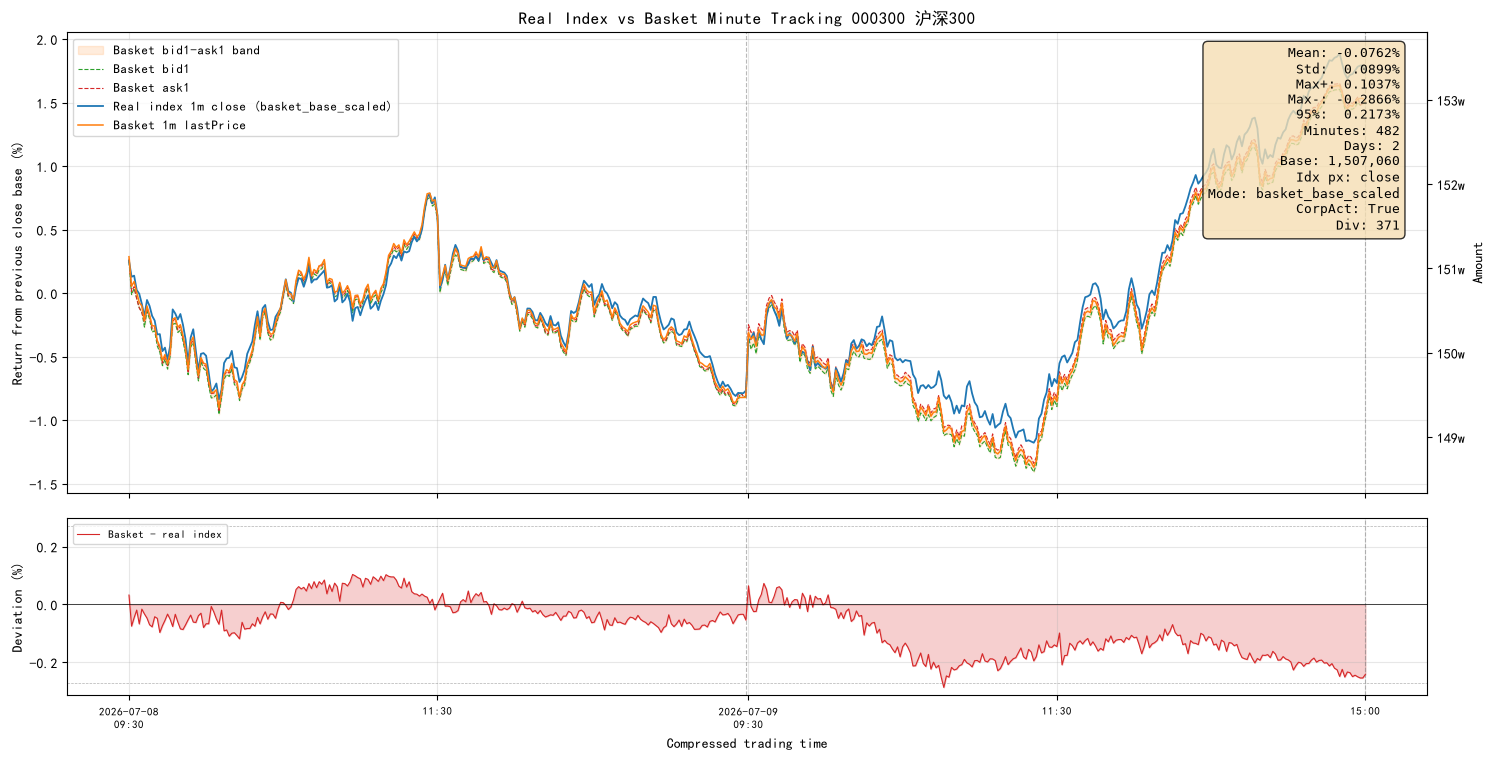

In [110]:
print("Baseline date:", baseline_date_dash)
print("Using ETF:", using_etf)
print("Weight source:", weight_source)
print("Portfolio method:", portfolio_greedy_method)
print("Close weight data date:", closeweight_data_date)
print("Fitting dates:", fitting_date_ls)
print("Adjusting dates:", adjusting_date_ls)
print("Rule file:", rule_file_path)
print("Target stock value:", target_stock_value)
print("Apply corporate actions:", apply_corporate_actions_to_basket)
print("Funding ratio cap:", adjustment_max_over_budget_ratio)
print("Real index price caliber:", real_index_price_caliber)
print("Real index amount mode:", real_index_amount_mode)
print("Risk estimator:", initial_risk_model.summary["estimator"])
print("Risk matrix mode:", risk_matrix_mode)
print("Risk lookback days:", risk_lookback_days)
print("Risk half-life days:", risk_half_life_days)
print("Risk price col:", risk_price_col)
print("OAS shrinkage:", initial_risk_model.summary["oas_shrinkage"])
print("Pareto config:", pareto_config)
print("Excepted stocks:", excepted_code_ls)
print("[Daily Tracking Stats]")
display(df_daily_tracking_stats[[
    "fitting_date", "diff_mean_pct", "diff_std_pct",
    "diff_max_positive_pct", "diff_max_negative_pct", "diff_pct95_pct",
    "n_minutes", "daily_dividend_cash", "cumulative_dividend_cash",
    "corporate_action_enabled", "real_index_base_price",
    "real_index_price_caliber", "real_index_amount_mode",
]])
print("[Quantity Adjustments]:", len(df_quantity_adjustments))
display(df_quantity_adjustments.head(10))
print("[Dividend Records]:", len(df_dividend_records))
display(df_dividend_records.tail(10))
print("[Adjustment Summary]")
display(df_adjustment_summary)
print("[Adjustment Trades]:", len(df_adjustment_trades))
display(df_adjustment_trades.head(10))
print("[Position Schedule]")
display(df_position_schedule.head(5))
print("[Benchmark Base By Date]")
display(df_benchmark_base_by_date)
display(outputs["matplotlib_fig"])
display(outputs["plotly_fig"])


In [111]:
f'{time.perf_counter():.1f}s'

'10212.2s'